In [2]:
'''Task 1: Data preparation and exploration

Load datasets, including transactions_fraud_train.csv, infrastructure_metrics.csv, and application_logs.csv
Clean the data by handling missing values and standardizing data types
Explore distributions of key business KPIs, such as success rates and processing times
Analyze infrastructure metrics, including CPU utilization, memory usage, and error rates
Correlate transaction performance with infrastructure load
Visualize patterns to identify system bottlenecks and anomalies
'''

'Task 1: Data preparation and exploration\n\nLoad datasets, including transactions_fraud_train.csv, infrastructure_metrics.csv, and application_logs.csv\nClean the data by handling missing values and standardizing data types\nExplore distributions of key business KPIs, such as success rates and processing times\nAnalyze infrastructure metrics, including CPU utilization, memory usage, and error rates\nCorrelate transaction performance with infrastructure load\nVisualize patterns to identify system bottlenecks and anomalies\n'

In [3]:
''''1a) Load datasets, including transactions_fraud_train.csv, infrastructure_metrics.csv, and application_logs.csv
Clean the data by handling missing values and standardizing data types '''


import pandas as pd
import numpy as np

#Load datasets, including transactions_fraud_train.csv, infrastructure_metrics.csv, and application_logs.csv
trans_fraud_train = "transactions_fraud_train.csv"
infra_metrics = "infrastructure_metrics_train.csv"
app_logs = "application_logs.csv"



df_trans_fraud_train = pd.read_csv(trans_fraud_train)
df_infra_metrics = pd.read_csv(infra_metrics)
df_app_logs = pd.read_csv(app_logs)

print("="*25, "transactions_fraud_train.csv", "="*25,"\n")
#Data Preprocess + Clean the data by handling missing values and standardizing data types

print(("Shape:", df_trans_fraud_train.shape))
print("\nColumn datatypes: ")
print(df_trans_fraud_train.dtypes)
print("\nDescribe:")
print(df_trans_fraud_train.describe())
print("\nCheck Any non-available cells by summing all the null cells:")
print(df_trans_fraud_train.isnull().sum())
print("\nMissing Values: ")
print(df_trans_fraud_train.isna().sum())
print("\nCheck for any duplicated rows:")
print(df_trans_fraud_train.duplicated().sum())
print("\nLets standardize date and time by converting data and time stored as strings in the cell into actual date and time that python can use and manipulate:")
df_trans_fraud_train["timestamp"] = pd.to_datetime(
    df_trans_fraud_train["timestamp"],
    errors="coerce"
)
print(df_trans_fraud_train["timestamp"].head(5))
print("\nLets clean up the columns by removing any spaces around the words: ")
trans_cat_cols= [
    "transaction_type",
    "merchant_category",
    "device_type",
    "location"
]

for col in trans_cat_cols:
  df_trans_fraud_train[col] = (
   df_trans_fraud_train[col].astype(str).str.strip()
  )


print("Data range: ")
print("\n",df_trans_fraud_train["is_fraud"].value_counts())
print("\nGroupby Device Type of whether or not it is Fraud: ")
print("\n",df_trans_fraud_train.groupby("device_type", as_index=False)["is_fraud"].value_counts())
print("\n",df_trans_fraud_train.groupby("location", as_index=False)["is_fraud"].value_counts())




print("="*25, "infrastructure_metrics_train.csv", "="*25,"\n")
print(("Shape:", df_infra_metrics.shape))
print("\nColumn datatypes: ")
print(df_infra_metrics.dtypes)
print("\nDescribe:")
print(df_infra_metrics.describe())
print("\nCheck Any non-available cells by summing all the null cells: ")
print(df_infra_metrics.isnull().sum())
print("\nMissing Values: ")
print(df_infra_metrics.isna().sum())
print("\nCheck for any duplicated rows")
print(df_infra_metrics.duplicated().sum())
print("\nLets standardize date and time by converting data and time stored as strings in the cells into actual date and time that python can use and manipulate:")
df_infra_metrics["timestamp"] = pd.to_datetime(
    df_infra_metrics["timestamp"],
    errors="coerce"
)
print(df_infra_metrics["timestamp"].head(5))





print("="*25, "application_logs.csv", "="*25,"\n")
print(("Shape: ",df_app_logs.shape))
print("\nColumn datatypes:")
print(df_app_logs.dtypes)
print("\nDescribe:")
print(df_app_logs.describe())
print("\nCheck any non-available cells by summing all the null cells:")
print(df_app_logs.isnull().sum())
print("\nMissing Values: ")
print(df_app_logs.isna().sum())
print("\nCheck for any duplicated rows: ")
print(df_app_logs.duplicated().sum())
print("\nLets standardize date and time by converting data and time stored as strings in the cell into actual date and time that python can use and manipulate: ")
df_app_logs["timestamp"] = pd.to_datetime(
    df_app_logs["timestamp"],
    errors="coerce"
)
print(df_app_logs["timestamp"].head(5))
print("\nLets clean up the columns by removing any spaces around the words:")
app_logs_cols = [
    "log_level",
    "log_message"
]

for col in app_logs_cols:
  df_app_logs[col] = (
      df_app_logs[col].astype(str).str.strip()
  )
print("Data Range: ")
print("\n",df_app_logs["log_level"].value_counts())
print("\nGroupby Log MEssage of what the Log Level is: ")
print("\n", df_app_logs.groupby("log_message", as_index=False)["log_level"].value_counts())


========================= transactions_fraud_train.csv ========================= 

('Shape:', (4000, 10))

Column datatypes: 
transaction_id         object
customer_id            object
timestamp              object
transaction_type       object
amount                float64
merchant_category      object
device_type            object
location               object
processing_time_ms    float64
is_fraud                int64
dtype: object

Describe:
             amount  processing_time_ms     is_fraud
count  4.000000e+03         4000.000000  4000.000000
mean   1.936434e+05         1040.235167     0.047750
std    3.702724e+05          535.154335     0.213263
min    2.444000e+01          100.250000     0.000000
25%    2.027435e+04          559.315000     0.000000
50%    4.602640e+04         1022.895000     0.000000
75%    1.640652e+05         1513.205000     0.000000
max    1.988806e+06         1999.000000     1.000000

Check Any non-available cells by summing all the null cells:
transactio


Lets look at the key performance indicators (KPIs) Success Rate: neft_success_rate, imps_success_rate, rtgs_success_rate, auth_success_rate from infrastructure_metrics_train.csv 


The Success Rate Summary Stats for neft, imps, rtgs, and auth:
       neft_success_rate  imps_success_rate  rtgs_success_rate  \
count        8064.000000        8064.000000        8064.000000   
mean           97.999611          99.013752          99.502099   
std             1.147202           0.576034           0.289540   
min            96.000000          98.000000          99.000000   
25%            97.030000          98.520000          99.260000   
50%            97.980000          99.030000          99.500000   
75%            98.990000          99.520000          99.750000   
max           100.000000         100.000000         100.000000   

       auth_success_rate  
count        8064.000000  
mean           98.965267  
std             0.381875  
min            96.510000  
25%            98.730000 

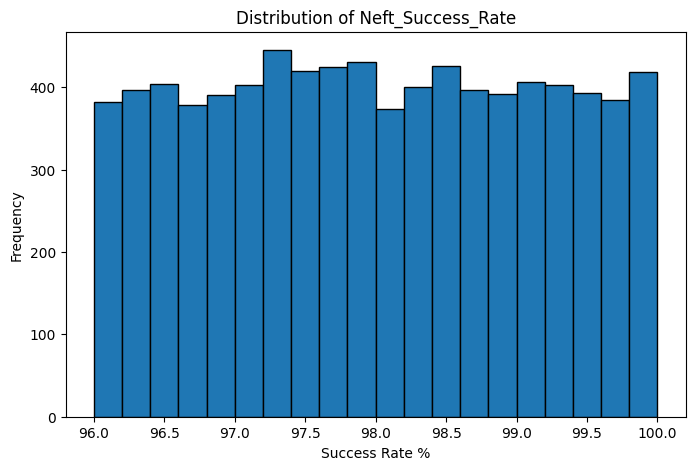

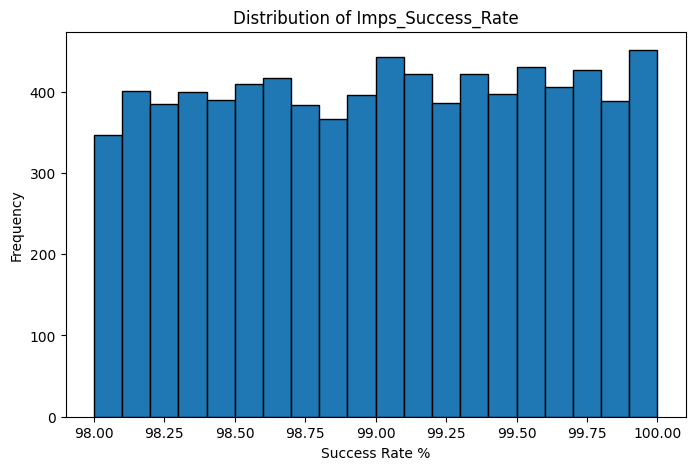

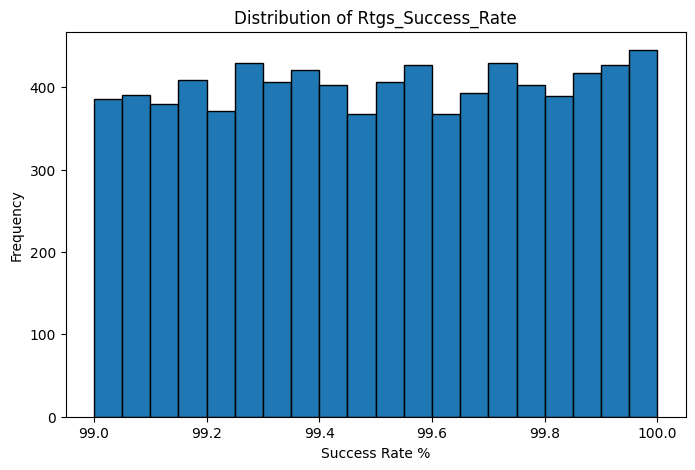

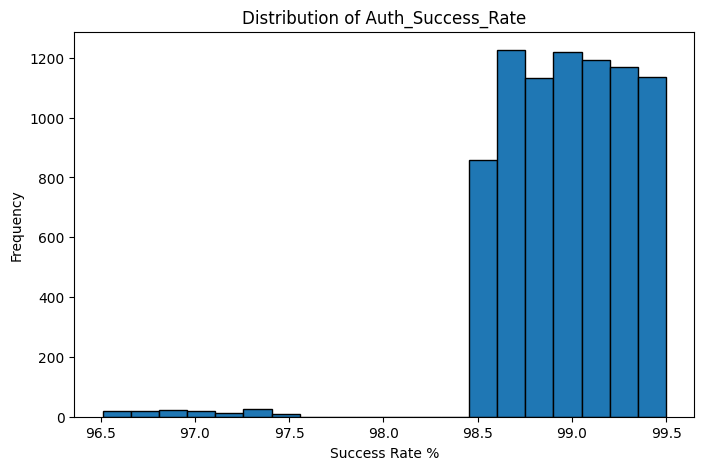


Lets plot the Success Rate Distribution for KPIs using Boxplot: 


/tmp/ipykernel_974/2921077686.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


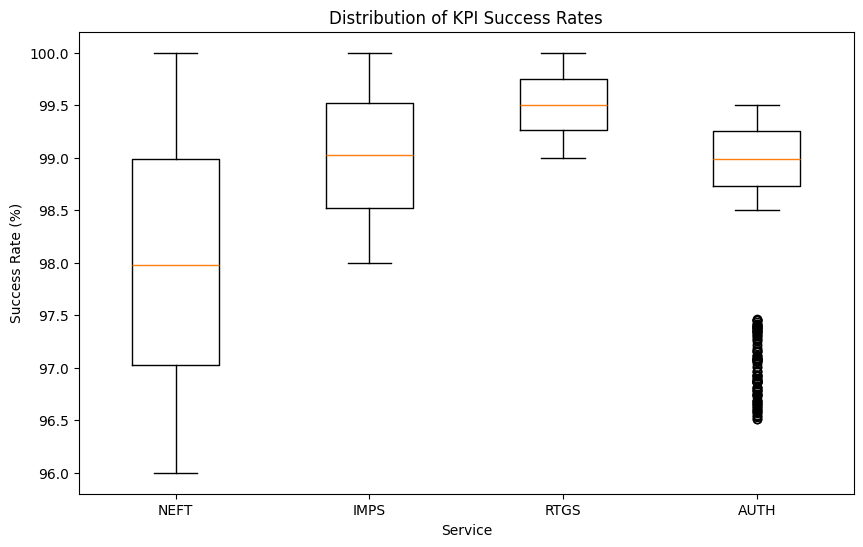


Lets plot the Infrastructure Processing Time Statistics using Histogram: 
<bound method NDFrame.describe of 0       108.99
1       100.00
2       102.10
3       100.00
4       135.61
         ...  
8059    163.06
8060    238.02
8061    183.81
8062    168.61
8063    236.89
Name: avg_transaction_processing_time_ms, Length: 8064, dtype: float64>


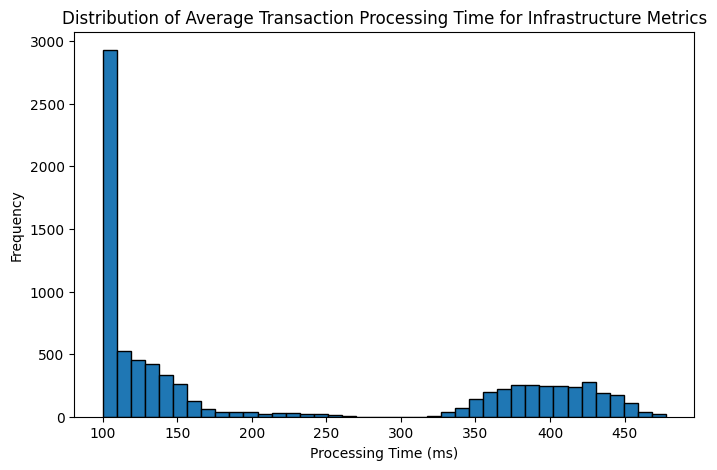


Processing Time by Fraud Status in Transactions_Fraud.csv


/tmp/ipykernel_974/2921077686.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


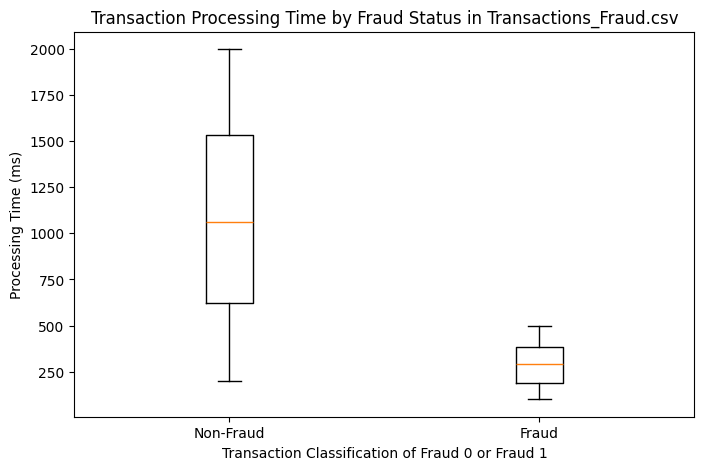


Lets Summarize the Processing Time by Fraud Status in Transactions_Fraud.csv

Processing Time by Fraud Status:
          count         mean   median         std     min      max
is_fraud                                                          
0          3809  1077.761357  1060.75  520.189349  200.24  1999.00
1           191   291.872565   293.58  114.897043  100.25   498.96

NEFT Success Rate has AVG Mean of: 97.999611% 
IMPS Success Rate has AVG Mean of: 99.013752% 
RTGS Success Rate has AVG Mean of 99.502099%
Authenticate Success Rate has AVG Mean of 98.965267%

Thus we can conclude that RTGS has the highest and most stable succes rate while NEFT Success Rate has highest Standard Deviation of 1.147202


In [4]:
'''1b) Explore distributions of key business KPIs/key performance indicators, such as success rates and processing times'''

import matplotlib.pyplot as plt
print("\nLets look at the key performance indicators (KPIs) Success Rate: neft_success_rate, imps_success_rate, rtgs_success_rate, auth_success_rate from infrastructure_metrics_train.csv \n")
success_rate_cols = [
    "neft_success_rate",
    "imps_success_rate",
    "rtgs_success_rate",
    "auth_success_rate"
]

print("\nThe Success Rate Summary Stats for neft, imps, rtgs, and auth:")
print(df_infra_metrics[success_rate_cols].describe())

print("\nLets plot the Success Rate distributions for KPIs using Histogram:")
for col in success_rate_cols:
  plt.figure(figsize=(8,5))
  plt.hist(
      df_infra_metrics[col],
      bins=20,
      edgecolor="black"
  )

  plt.title(f"Distribution of {col.title()}")
  plt.xlabel("Success Rate %")
  plt.ylabel("Frequency")

  plt.show()

print("\nLets plot the Success Rate Distribution for KPIs using Boxplot: ")
plt.figure(figsize=(10,6))
plt.boxplot(
    df_infra_metrics[success_rate_cols],
    labels=[
        "NEFT",
        "IMPS",
        "RTGS",
        "AUTH"
    ]
)
plt.title("Distribution of KPI Success Rates")
plt.ylabel("Success Rate (%)")
plt.xlabel("Service")
plt.show()

print("\nLets plot the Infrastructure Processing Time Statistics using Histogram: ")
print(
    df_infra_metrics[
        "avg_transaction_processing_time_ms"
    ].describe
)

plt.figure(figsize=(8,5))
plt.hist(
    df_infra_metrics["avg_transaction_processing_time_ms"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Average Transaction Processing Time for Infrastructure Metrics")
plt.xlabel("Processing Time (ms)")
plt.ylabel("Frequency")
plt.show()

print("\nProcessing Time by Fraud Status in Transactions_Fraud.csv")
fraud_groups = df_trans_fraud_train.groupby("is_fraud")["processing_time_ms"]
fraud_0 = fraud_groups.get_group(0)
fraud_1 = fraud_groups.get_group(1)

plt.figure(figsize=(8,5))
plt.boxplot(
    [fraud_0, fraud_1],
    labels=["Non-Fraud", "Fraud"]
)

plt.title("Transaction Processing Time by Fraud Status in Transactions_Fraud.csv")
plt.xlabel("Transaction Classification of Fraud 0 or Fraud 1")
plt.ylabel("Processing Time (ms)")
plt.show()

print("\nLets Summarize the Processing Time by Fraud Status in Transactions_Fraud.csv")
print("\nProcessing Time by Fraud Status:")
print(
    df_trans_fraud_train.groupby("is_fraud")[
        "processing_time_ms"
    ].agg(["count","mean","median","std","min","max"])
)
print("\nNEFT Success Rate has AVG Mean of: 97.999611% \nIMPS Success Rate has AVG Mean of: 99.013752% \nRTGS Success Rate has AVG Mean of 99.502099%\nAuthenticate Success Rate has AVG Mean of 98.965267%")
print("\nThus we can conclude that RTGS has the highest and most stable succes rate while NEFT Success Rate has highest Standard Deviation of 1.147202")

========================= infrastructure_metrics_train.csv KPI Summary ========================= 


        cpu_utilization  memory_usage  application_error_rate  \
count      8064.000000   8064.000000             8064.000000   
mean         50.459721     45.379962                1.992684   
std          14.332759     12.759284                1.416342   
min          32.900000     30.860000                0.000000   
25%          39.100000     35.350000                1.000000   
50%          43.010000     37.790000                2.000000   
75%          67.512500     61.450000                3.000000   
max          77.520000     68.160000               10.000000   

       avg_transaction_processing_time_ms  transaction_volume_per_hour  
count                         8064.000000                  8064.000000  
mean                           213.094688                  5040.651910  
std                            135.797470                  1505.794154  
min                           

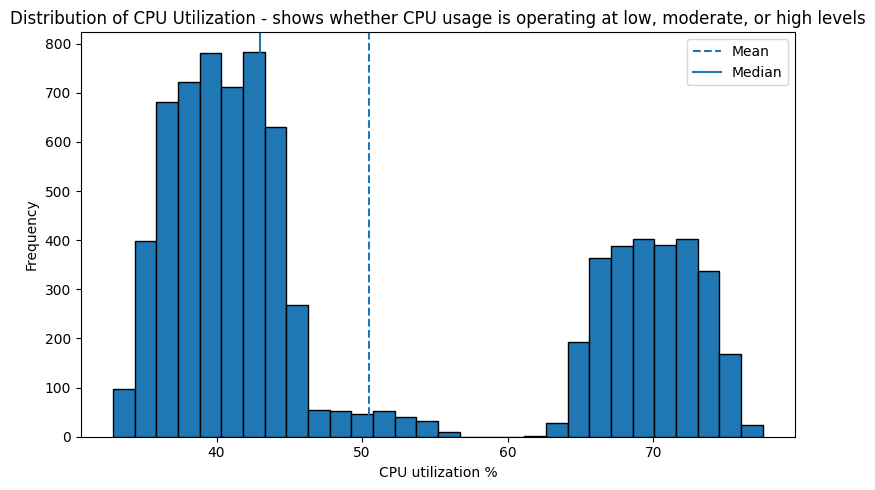


Scatterplot of Transaction Time vs. CPU Utilization in Infrastructure_metrics.csv


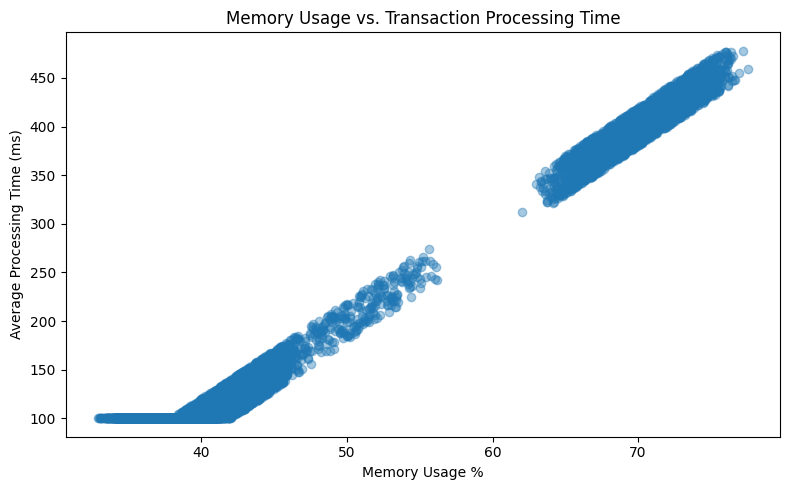


Scatterplot of Transaction Volume vs. Processing Time in Infrastructure_metrics.csv 


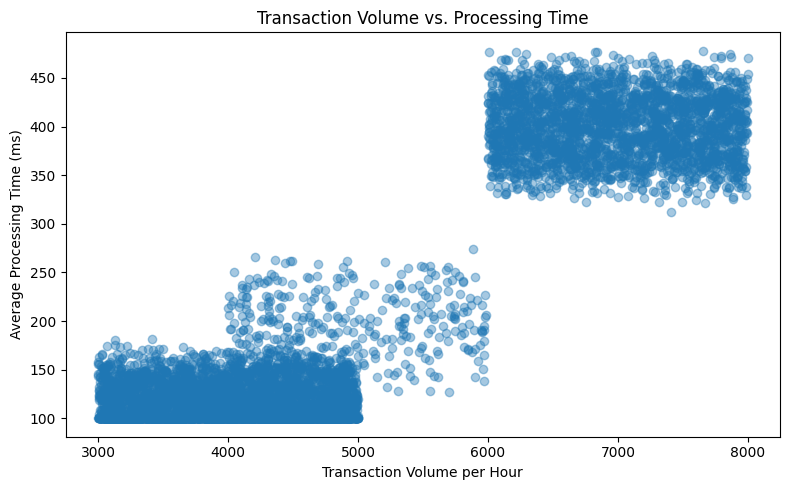


Scatterplot of CPU Utilization vs. Application Error Rate


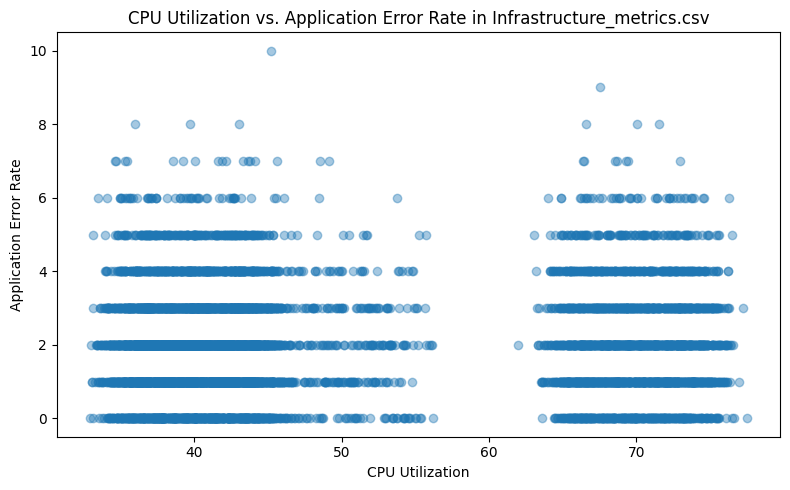


High CPU Usage:                 timestamp  cpu_utilization  memory_usage  \
540  2025-10-20 09:00:00            72.98         64.63   
541  2025-10-20 09:01:00            72.75         65.84   
542  2025-10-20 09:02:00            65.57         64.33   
543  2025-10-20 09:03:00            74.28         63.85   
544  2025-10-20 09:04:00            68.18         59.46   
...                  ...              ...           ...   
6835 2025-10-24 17:55:00            72.00         63.86   
6836 2025-10-24 17:56:00            69.16         59.21   
6837 2025-10-24 17:57:00            69.83         63.65   
6838 2025-10-24 17:58:00            73.53         61.21   
6839 2025-10-24 17:59:00            66.83         66.48   

      db_connection_pool_usage  network_throughput_mbps  \
540                      56.36                   368.33   
541                      53.66                   381.06   
542                      60.58                   329.34   
543                      53.93       

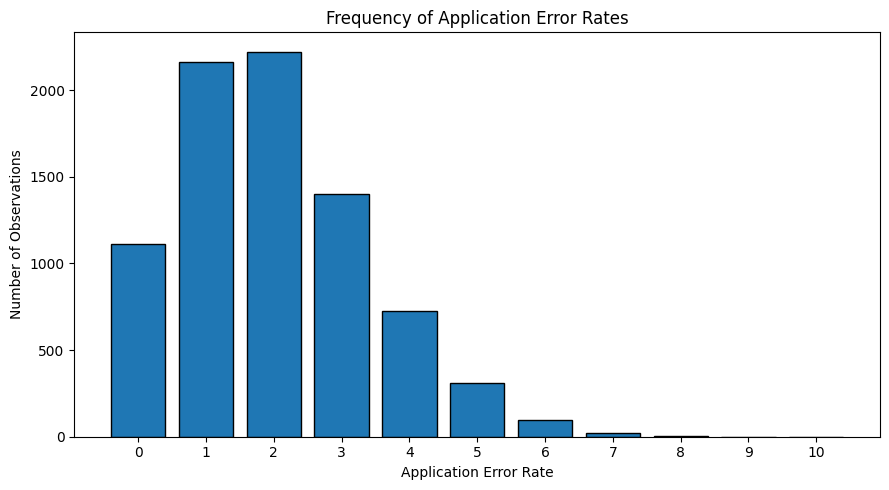

========================= High Error Rate Observations ========================= 


Lets print out the top 10 error rate observations:
   index           timestamp  cpu_utilization  memory_usage  \
0   7405 2025-10-25 03:25:00            45.22         36.80   
1   6368 2025-10-24 10:08:00            67.56         65.50   
2   4889 2025-10-23 09:29:00            70.03         64.01   
3   2440 2025-10-21 16:40:00            66.60         62.58   
4   6783 2025-10-24 17:03:00            71.57         64.03   
5   1512 2025-10-21 01:12:00            35.96         36.95   
6     80 2025-10-20 01:20:00            39.68         37.97   
7   4137 2025-10-22 20:57:00            43.04         35.51   
8   1270 2025-10-20 21:10:00            34.60         35.47   
9   3440 2025-10-22 09:20:00            68.57         61.87   

   application_error_rate  avg_transaction_processing_time_ms  \
0                      10                              165.17   
1                       9                

In [5]:
'''1c) Analyze infrastructure metrics, including CPU utilization, memory usage, and error rates
'''
df_infra_metrics["timestamp"] = pd.to_datetime(
    df_infra_metrics["timestamp"],
    errors="coerce"
)

df_infra_metrics = (
    df_infra_metrics
    .sort_values("timestamp")
    .reset_index(drop=True)
)

infra_cols = [
    "cpu_utilization",
    "memory_usage",
    "application_error_rate",
    "avg_transaction_processing_time_ms",
    "transaction_volume_per_hour"
]

print("="*25, "infrastructure_metrics_train.csv KPI Summary", "="*25,"\n")
print("\n", df_infra_metrics[infra_cols].describe())

print("\nLets demonstrate CPU Utilization Distribution with axvline representing where the mean is:")
plt.figure(figsize=(8,5))

plt.hist(
    df_infra_metrics["cpu_utilization"],
    bins=30,
    edgecolor="black"
)

plt.axvline(
    df_infra_metrics["cpu_utilization"].mean(),
    linestyle="--",
    label="Mean"
)

plt.axvline(
    df_infra_metrics["cpu_utilization"].median(),
    linestyle="-",
    label="Median"
)

plt.title("Distribution of CPU Utilization - shows whether CPU usage is operating at low, moderate, or high levels")
plt.xlabel("CPU utilization %")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

print("\nScatterplot of Transaction Time vs. CPU Utilization in Infrastructure_metrics.csv")
plt.figure(figsize=(8,5))
plt.scatter(
  df_infra_metrics["cpu_utilization"],
  df_infra_metrics["avg_transaction_processing_time_ms"],
  alpha=0.4
)

plt.title("Memory Usage vs. Transaction Processing Time")
plt.xlabel("Memory Usage %")
plt.ylabel("Average Processing Time (ms)")

plt.tight_layout()
plt.show()

print("\nScatterplot of Transaction Volume vs. Processing Time in Infrastructure_metrics.csv ")

plt.figure(figsize=(8,5))

plt.scatter(
    df_infra_metrics["transaction_volume_per_hour"],
    df_infra_metrics["avg_transaction_processing_time_ms"],
    alpha=0.4
)

plt.title("Transaction Volume vs. Processing Time")
plt.xlabel("Transaction Volume per Hour")
plt.ylabel("Average Processing Time (ms)")

plt.tight_layout()
plt.show()

print("\nScatterplot of CPU Utilization vs. Application Error Rate")
plt.figure(figsize=(8,5))

plt.scatter(
    df_infra_metrics["cpu_utilization"],
    df_infra_metrics["application_error_rate"],
    alpha=0.4
)

plt.title("CPU Utilization vs. Application Error Rate in Infrastructure_metrics.csv")
plt.xlabel("CPU Utilization")
plt.ylabel("Application Error Rate")

plt.tight_layout()
plt.show()

high_cpu = df_infra_metrics[
    df_infra_metrics["cpu_utilization"] >=65
]

high_memory = df_infra_metrics[
    df_infra_metrics["memory_usage"] >=65

]

print("\nHigh CPU Usage: ", high_cpu)
print("\nHigh Memory Usage: ", high_memory)

print("="*25, "Error Rate Frequency Barchart", "="*25,"\n")

error_counts = (
    df_infra_metrics["application_error_rate"].value_counts().sort_index()
)

plt.figure(figsize=(9,5))
plt.bar(
    error_counts.index.astype(str),
    error_counts.values,
    edgecolor="black"
)

plt.title("Frequency of Application Error Rates")
plt.xlabel("Application Error Rate")
plt.ylabel("Number of Observations")

plt.tight_layout()
plt.show()

print("="*25, "High Error Rate Observations", "="*25,"\n")

print("\nLets print out the top 10 error rate observations:")
top_errors = (
    df_infra_metrics[
        [
          "timestamp",
          "cpu_utilization",
          "memory_usage",
          "application_error_rate",
          "avg_transaction_processing_time_ms",
          "transaction_volume_per_hour"
        ]
    ]
    .sort_values(
        "application_error_rate",
        ascending=False,

    )
    .head(10).reset_index()
)

print(top_errors)

print("="*25, "Highest CPU Utilization Observations", "="*25,"\n")
print("\nLets print the top 10 CPU Utilization Observations: ")
top_cpu = (
    df_infra_metrics[
        [
          "timestamp",
          "cpu_utilization",
          "memory_usage",
          "application_error_rate",
          "avg_transaction_processing_time_ms",
          "transaction_volume_per_hour"
        ]
    ]
    .sort_values(
        "cpu_utilization",
        ascending=False
    )
    .head(10).reset_index()
)
print(top_cpu)



Infrastructure data is recorded every minute according to Timestamp. Thus, lets match each transaction to the closest infrastructure observation within 1 minute using direction='nearest'.
     transaction_id customer_id           timestamp transaction_type  \
0     TXN0000007496  CUST001376 2025-08-05 01:57:34              UPI   
1     TXN0000008106  CUST001483 2025-08-05 02:03:34             IMPS   
2     TXN0000007318  CUST001347 2025-08-05 02:39:34              UPI   
3     TXN0000026556  CUST004849 2025-08-05 02:52:38             NEFT   
4     TXN0000024596  CUST004485 2025-08-05 03:34:37              UPI   
...             ...         ...                 ...              ...   
3995  TXN0000003602  CUST000649 2025-11-02 23:06:33     Card_Payment   
3996  TXN0000021124  CUST003836 2025-11-02 23:23:37              UPI   
3997  TXN0000017373  CUST003165 2025-11-02 23:54:36              UPI   
3998  TXN0000026493  CUST004837 2025-11-03 00:06:38              UPI   
3999  TXN0000015050

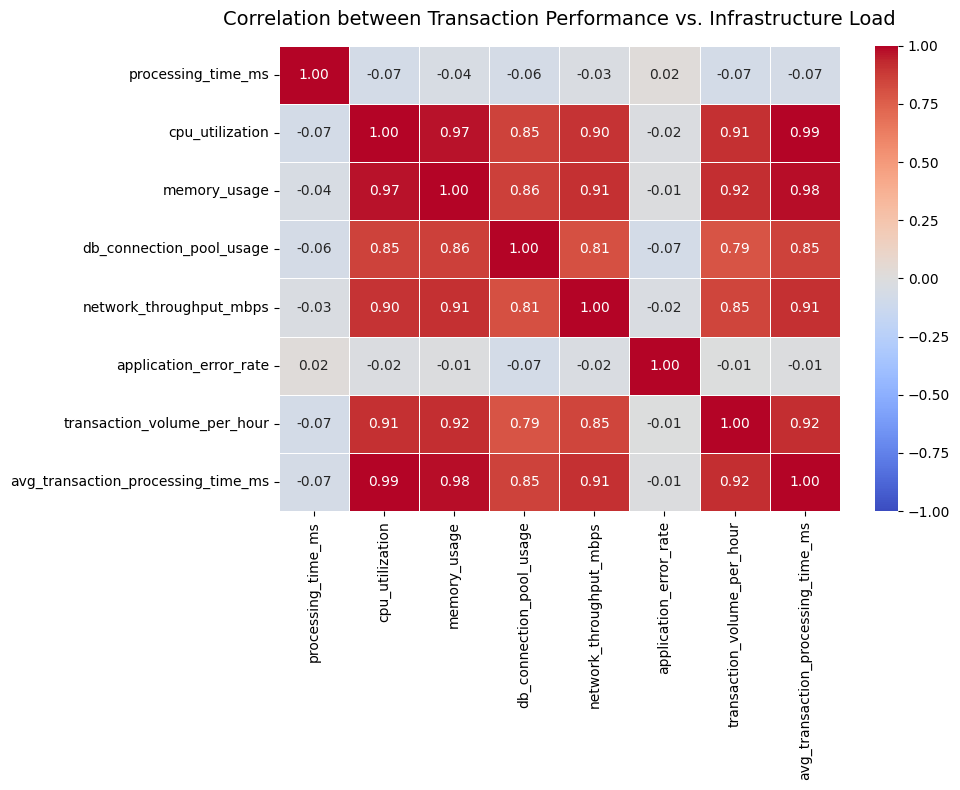


Correlation with Individual Transaction Processing Time:
application_error_rate                0.017809
network_throughput_mbps              -0.028217
memory_usage                         -0.040520
db_connection_pool_usage             -0.063550
avg_transaction_processing_time_ms   -0.067612
transaction_volume_per_hour          -0.070350
cpu_utilization                      -0.070517
Name: processing_time_ms, dtype: float64

Infrastructure Processing Time Correlations such that Infrastructure Load vs Average Processing Time
cpu_utilization                0.993473
memory_usage                   0.974947
network_throughput_mbps        0.910798
transaction_volume_per_hour    0.908027
db_connection_pool_usage       0.874225
application_error_rate         0.007010
Name: avg_transaction_processing_time_ms, dtype: float64

Lets create a heatmap for our correlation matrix: 


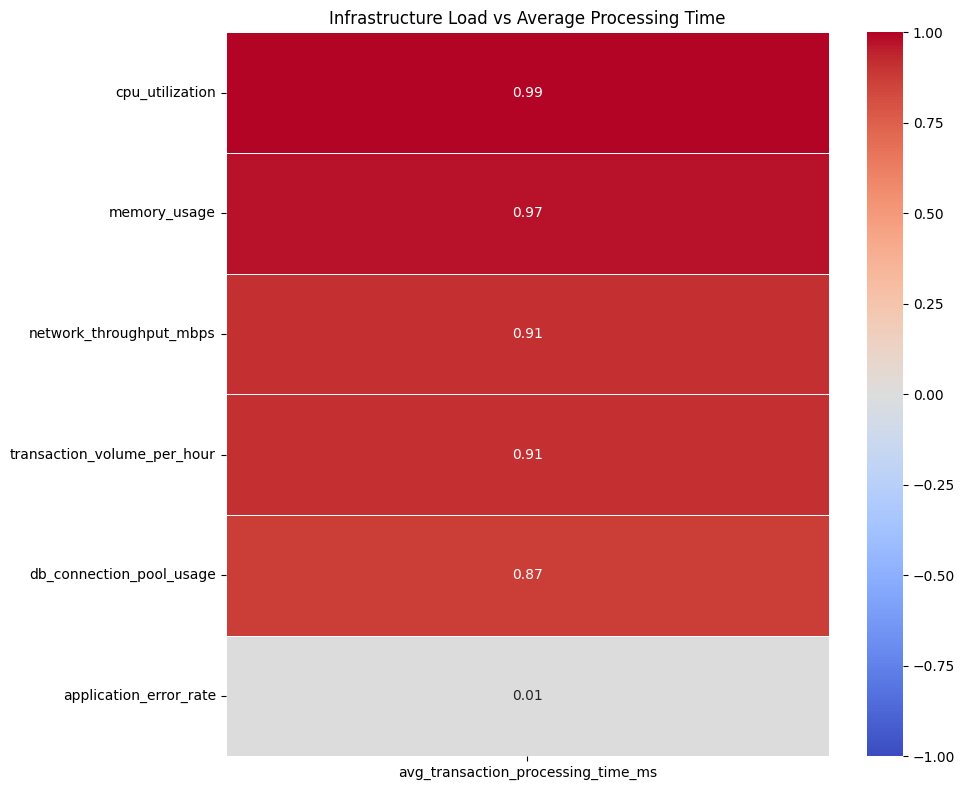

In [6]:
'''1d) Correlate transaction performance with infrastructure load'''
import seaborn as sns

df_trans_fraud_train["timestamp"] = pd.to_datetime(
    df_trans_fraud_train["timestamp"],
    errors="coerce"
)

df_infra_metrics["timestamp"] = pd.to_datetime(
    df_infra_metrics["timestamp"],
    errors="coerce"
)

transactions_sorted = (
    df_trans_fraud_train.sort_values("timestamp").reset_index(drop=True)
)

infra_sorted = (
    df_infra_metrics.sort_values("timestamp").reset_index(drop=True)
)

print("\nInfrastructure data is recorded every minute according to Timestamp. Thus, lets match each transaction to the closest infrastructure observation within 1 minute using direction='nearest'.")
df_transaction_infra=pd.merge_asof(
    transactions_sorted,
    infra_sorted,
    on="timestamp",
    direction="nearest",
    tolerance=pd.Timedelta("1min") #pandas will fill the infras column with n/a if closest infras log is 61 seconds away
)
print(df_transaction_infra)

df_transaction_infra = df_transaction_infra.dropna(
    subset=["cpu_utilization"]
).reset_index(drop=True)

print("="*25, "Transaction / Infrastruction Matching", "="*25,"\n")

print("The number of Matched Transactions are:")
len(df_transaction_infra)

print("\nLets select specific columns to show correlation matrix:")

correlation_cols = [
    "processing_time_ms",
    "cpu_utilization",
    "memory_usage",
    "db_connection_pool_usage",
    "network_throughput_mbps",
    "application_error_rate",
    "transaction_volume_per_hour",
    "avg_transaction_processing_time_ms"
]

correlation_matrix= (
    df_transaction_infra[correlation_cols].corr()
)

print("="*25, "Transaction Performance vs. Infrastructure Correlation", "="*25,"\n")


print(correlation_matrix)

plt.figure(figsize=(10,8))

print("\nLets create a heatmap for our correlation matrix: ")
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title("Correlation between Transaction Performance vs. Infrastructure Load", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

processing_correlations = (
    correlation_matrix["processing_time_ms"].drop("processing_time_ms").sort_values(ascending=False)
)

print("\nCorrelation with Individual Transaction Processing Time:")
print(processing_correlations)

print("\nInfrastructure Processing Time Correlations such that Infrastructure Load vs Average Processing Time")
infra_performance_cols = [
    "avg_transaction_processing_time_ms",
    "cpu_utilization",
    "memory_usage",
    "db_connection_pool_usage",
    "network_throughput_mbps",
    "transaction_volume_per_hour",
    "application_error_rate"
]

infra_performance_corr = (
    df_infra_metrics[infra_performance_cols].corr()["avg_transaction_processing_time_ms"].drop("avg_transaction_processing_time_ms").sort_values(ascending=False)
)
print(infra_performance_corr)
print("\nLets create a heatmap for our correlation matrix: ")
plt.figure(figsize=(10,8))
sns.heatmap(
    infra_performance_corr.to_frame(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title("Infrastructure Load vs Average Processing Time")
plt.tight_layout()
plt.show()

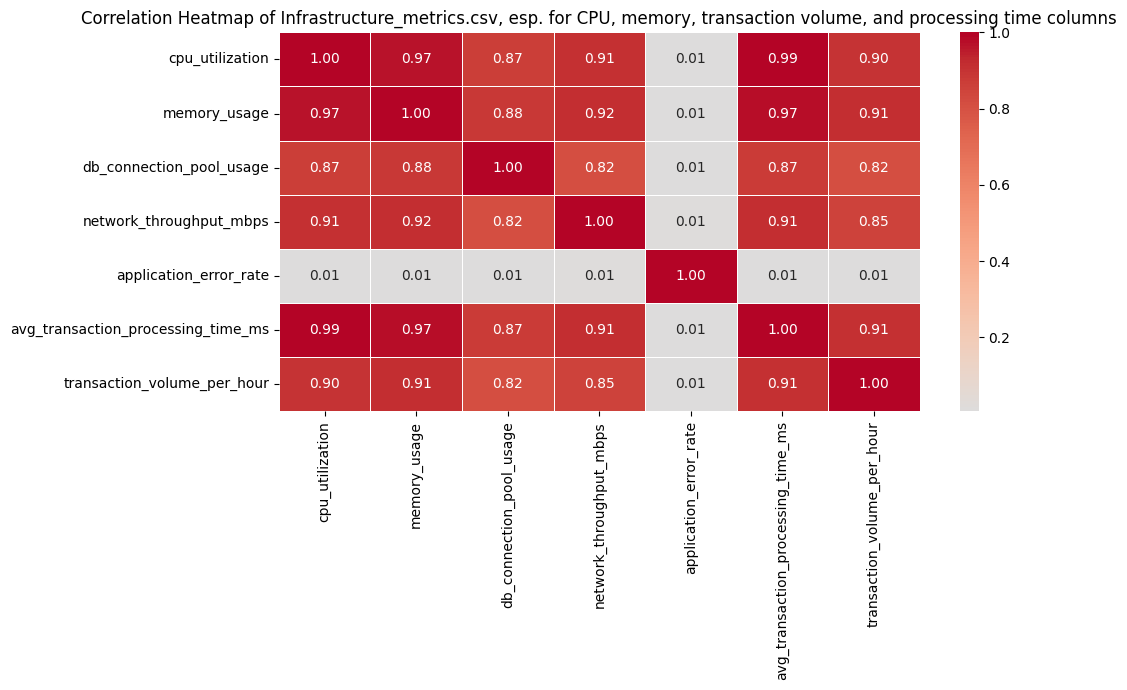


Thus, when CPU usage increases, transaction processing time also increase. CPU usage appears to be one of the main system bottlenecks. 
High CPU utilization is associated with slower transaction processing

Memory usage also contributes to slower performance (CPU and memory consumption increase together during heavy system activities)

Higher transaction volume means higher CPU/memory/database utilization and higher increased processing time

Lets Calculate High-Load Thresholds by utilizing 95th percentile to identify high values
========================= 95th Percential Bottleneck Thresholds ========================= 

CPU Utilization: 73.56%
Memory Usage: 65.17%
DB Connection Pool Usage: 62.76%
Processing Time: 436.26ms
Transaction Volume:  7683.00

We have to create bottleneck flags to alert: 

Lets Treat 3 or more simulatenous high load conditions as a significant bottleneck period

The Number of significant Bottleneck Observations: 162


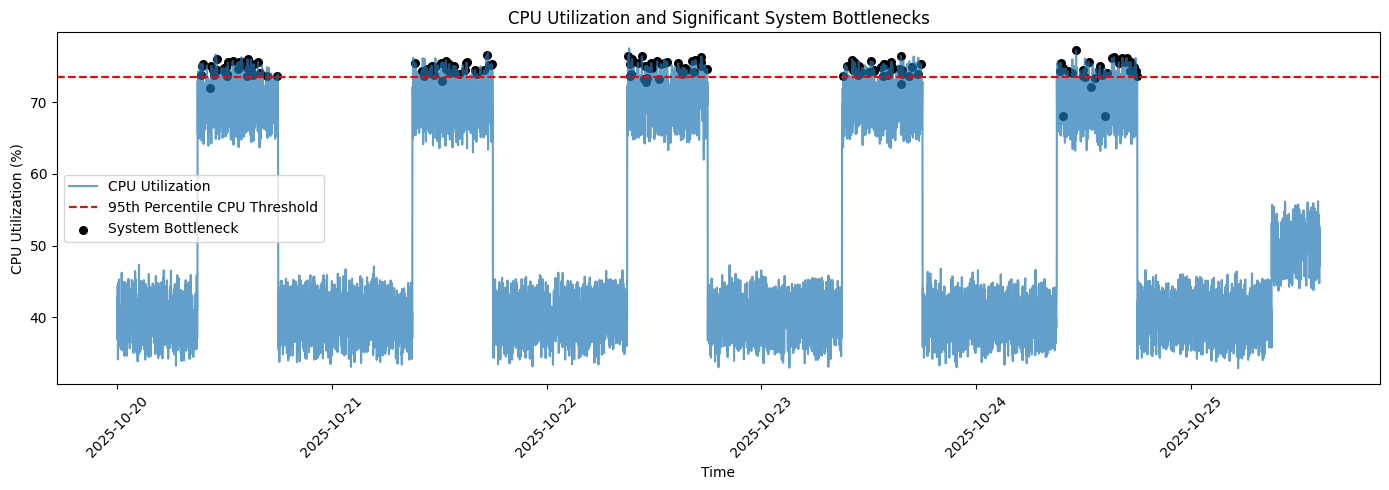


The black dots represent periods where at least 3 high-load conditions occurred simultaneously.


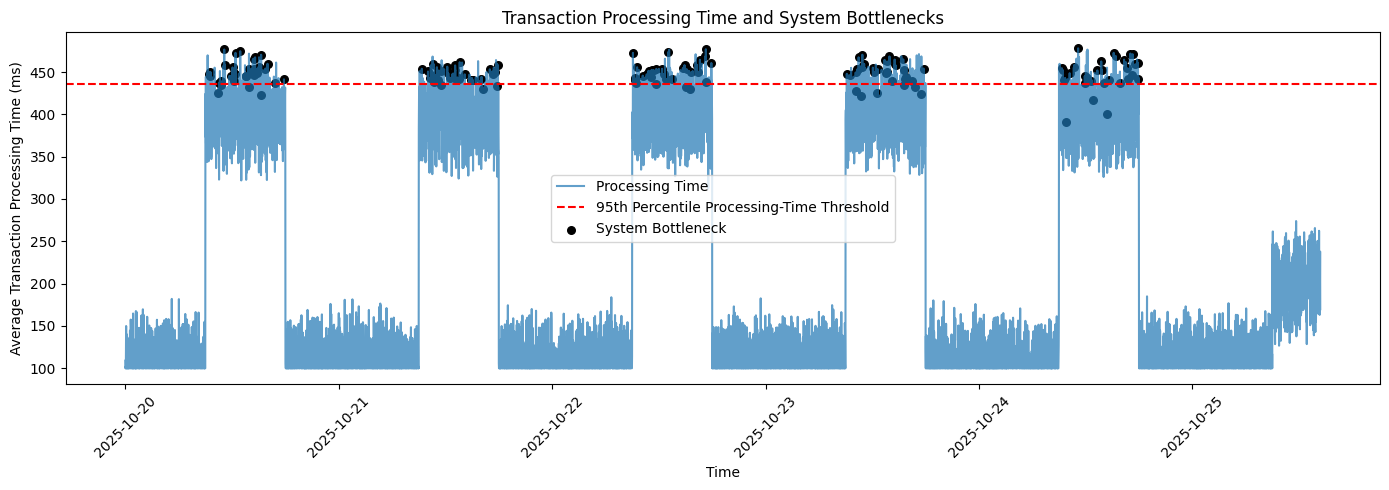


Using the 95th percentile as our threshold, there were 162 observations identied where at least the three, transaction/CPU/Memory/Database demand conditions when elevated
 represented significant system bottleneck periods. These caused performance issues.


In [7]:
'''1e) Visualize patterns to identify system bottlenecks and anomalies'''

df_infra_metrics["timestamp"] = pd.to_datetime(
    df_infra_metrics["timestamp"],
    errors="coerce"
)

df_infra_metrics = (
    df_infra_metrics.sort_values("timestamp").reset_index(drop=True)
)

df_infra_metrics["date"] = df_infra_metrics["timestamp"].dt.date
df_infra_metrics["hour"] = df_infra_metrics["timestamp"].dt.hour

bottleneck_cols = [
    "cpu_utilization",
    "memory_usage",
    "db_connection_pool_usage",
    "network_throughput_mbps",
    "application_error_rate",
    "avg_transaction_processing_time_ms",
    "transaction_volume_per_hour"
]

corr_matrix = (
    df_infra_metrics[bottleneck_cols].corr()
)
plt.figure(figsize=(11,7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidth=0.5
)

plt.title(
    "Correlation Heatmap of Infrastructure_metrics.csv, esp. for CPU, memory, transaction volume, and processing time columns"
)
plt.tight_layout()
plt.show()

print("\nThus, when CPU usage increases, transaction processing time also increase. CPU usage appears to be one of the main system bottlenecks. \nHigh CPU utilization is associated with slower transaction processing")
print("\nMemory usage also contributes to slower performance (CPU and memory consumption increase together during heavy system activities)")
print("\nHigher transaction volume means higher CPU/memory/database utilization and higher increased processing time")


print("\nLets Calculate High-Load Thresholds by utilizing 95th percentile to identify high values")

cpu_threshold = df_infra_metrics[
    "cpu_utilization"
].quantile(0.95)

memory_threshold = df_infra_metrics[
    "memory_usage"
].quantile(0.95)

db_threshold = df_infra_metrics[
    "db_connection_pool_usage"
].quantile(0.95)

processing_threshold = df_infra_metrics[
    "avg_transaction_processing_time_ms"
].quantile(0.95)

volume_threshold =df_infra_metrics[
    "transaction_volume_per_hour"
].quantile(0.95)

print("="*25, "95th Percential Bottleneck Thresholds", "="*25,"\n")
print(f"CPU Utilization: {cpu_threshold:.2f}%")
print(f"Memory Usage: {memory_threshold:.2f}%")
print(f"DB Connection Pool Usage: {db_threshold:.2f}%")
print(f"Processing Time: {processing_threshold:.2f}ms")
print(f"Transaction Volume: {volume_threshold: .2f}")

print("\nWe have to create bottleneck flags to alert: ")
df_infra_metrics["high_cpu"] = (
    df_infra_metrics["cpu_utilization"] >= cpu_threshold
)

df_infra_metrics["high_memory"] = (
    df_infra_metrics["memory_usage"] >=memory_threshold
)

df_infra_metrics["high_db"] = (
    df_infra_metrics["db_connection_pool_usage"] >= db_threshold
)

df_infra_metrics["high_processing_time"] = (
    df_infra_metrics["avg_transaction_processing_time_ms"] >= processing_threshold
)

df_infra_metrics["high_volume"] = (
    df_infra_metrics["transaction_volume_per_hour"] >=volume_threshold
)

flag_cols = [
    "high_cpu",
    "high_memory",
    "high_db",
    "high_processing_time",
    "high_volume"
]

df_infra_metrics["bottleneck_count"] = (
    df_infra_metrics[flag_cols].sum(axis=1)
)

print("\nLets Treat 3 or more simulatenous high load conditions as a significant bottleneck period")

df_infra_metrics["system_bottleneck"] = (
    df_infra_metrics["bottleneck_count"]>=3
)

print("\nThe Number of significant Bottleneck Observations:", df_infra_metrics["system_bottleneck"].sum())

plt.figure(figsize=(14,5))

plt.plot(
    df_infra_metrics["timestamp"],
    df_infra_metrics["cpu_utilization"],
    label="CPU Utilization",
    alpha=0.7
)

plt.axhline(
    cpu_threshold,
    color="red",
    linestyle="--",
    label="95th Percentile CPU Threshold"
)

bottlenecks = df_infra_metrics[
    df_infra_metrics["system_bottleneck"]
]

plt.scatter(
    bottlenecks["timestamp"],
    bottlenecks["cpu_utilization"],
    color="black",
    marker="o",
    s=30,
    label="System Bottleneck"
)

plt.title("CPU Utilization and Significant System Bottlenecks")
plt.xlabel("Time")
plt.ylabel("CPU Utilization (%)")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(
    "\nThe black dots represent periods where at least "
    "3 high-load conditions occurred simultaneously."
)






plt.figure(figsize=(14,5))

plt.plot(
    df_infra_metrics["timestamp"],
    df_infra_metrics["avg_transaction_processing_time_ms"],
    label="Processing Time",
    alpha=0.7
)

plt.axhline(
    processing_threshold,
    color="red",
    linestyle="--",
    label="95th Percentile Processing-Time Threshold"
)

plt.scatter(
    bottlenecks["timestamp"],
    bottlenecks["avg_transaction_processing_time_ms"],
    color="black",
    marker="o",
    s=30,
    label="System Bottleneck"
)

plt.title("Transaction Processing Time and System Bottlenecks")
plt.xlabel("Time")
plt.ylabel("Average Transaction Processing Time (ms)")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nUsing the 95th percentile as our threshold, there were 162 observations identied where at least the three, transaction/CPU/Memory/Database demand conditions when elevated\n represented significant system bottleneck periods. These caused performance issues.")



In [8]:
'''Task 2: Machine learning and predictive modeling

Implement time-series forecasting models to predict transaction success rates, API latency, and resource utilization
Build a classification model to predict incident criticality based on KPIs
Apply anomaly detection to identify unusual metric behavior
Evaluate model performance using metrics such as RMSE, MAE, Accuracy, and F1-score
Save trained models for deployment'''

'Task 2: Machine learning and predictive modeling\n\nImplement time-series forecasting models to predict transaction success rates, API latency, and resource utilization\nBuild a classification model to predict incident criticality based on KPIs\nApply anomaly detection to identify unusual metric behavior\nEvaluate model performance using metrics such as RMSE, MAE, Accuracy, and F1-score\nSave trained models for deployment'

In [9]:
!pip install scikit-learn


The target variables we want to predict are overall success rate, avg transaction processing time, cpu utilization, memory usage.

We will need to create time-series features that the computer can understand by building lag features/time features that the models can look backward in time to predict what happens next


Lets run forecasting using models for each target

----------------------------------------
Forecasting: overall_success_rate
------------------------------------------------------------
Training rows:  6443
Testing rows:  1611
Random Forest MAE: 0.288
XGBoost MAE: 0.282
Ridge MAE: 0.282
Lasso MAE: 0.282

Best Model: XGBoost
Best MAE: 0.282


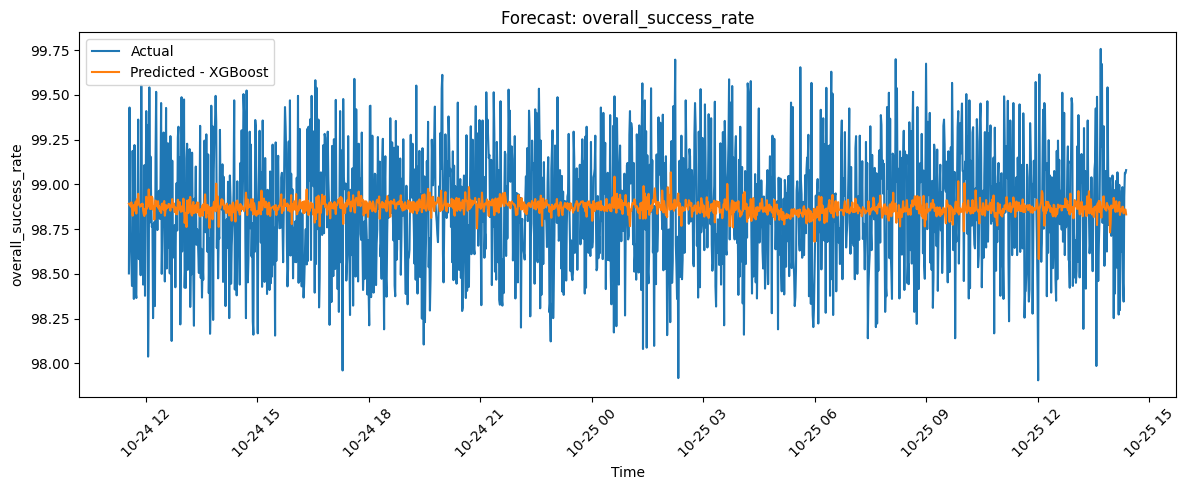


----------------------------------------
Forecasting: avg_transaction_processing_time_ms
------------------------------------------------------------
Training rows:  6443
Testing rows:  1611
Random Forest MAE: 32.543
XGBoost MAE: 47.712
Ridge MAE: 24.599
Lasso MAE: 24.602

Best Model: Ridge
Best MAE: 24.599


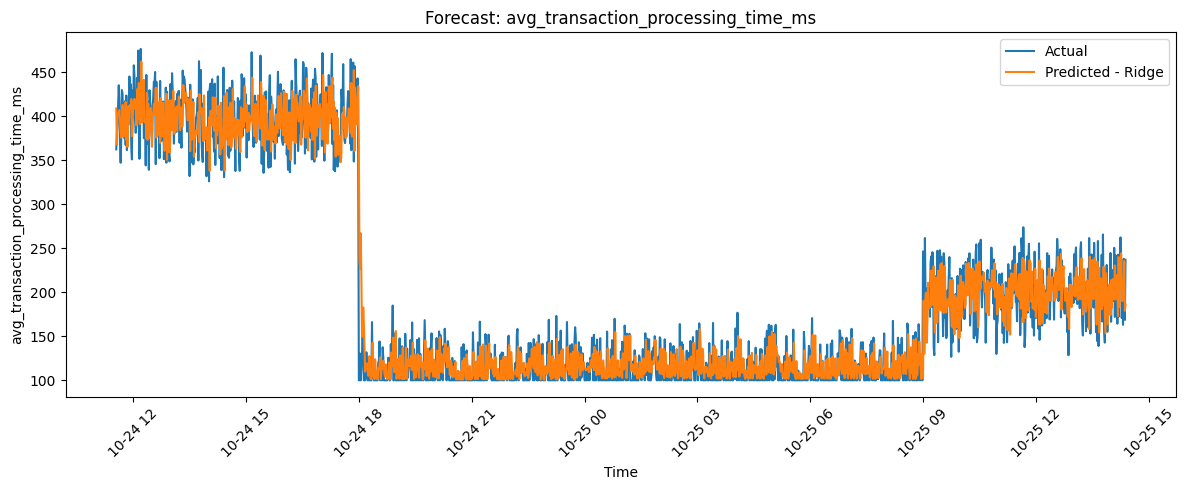


----------------------------------------
Forecasting: cpu_utilization
------------------------------------------------------------
Training rows:  6443
Testing rows:  1611
Random Forest MAE: 4.028
XGBoost MAE: 5.383
Ridge MAE: 2.994
Lasso MAE: 2.994

Best Model: Lasso
Best MAE: 2.994


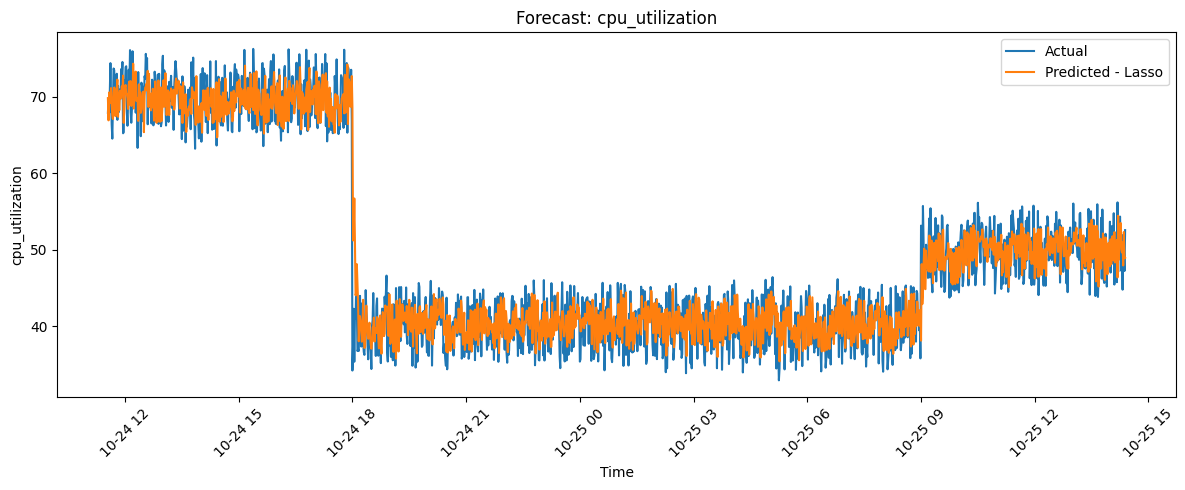


----------------------------------------
Forecasting: memory_usage
------------------------------------------------------------
Training rows:  6443
Testing rows:  1611
Random Forest MAE: 3.063
XGBoost MAE: 4.531
Ridge MAE: 1.910
Lasso MAE: 1.910

Best Model: Lasso
Best MAE: 1.910


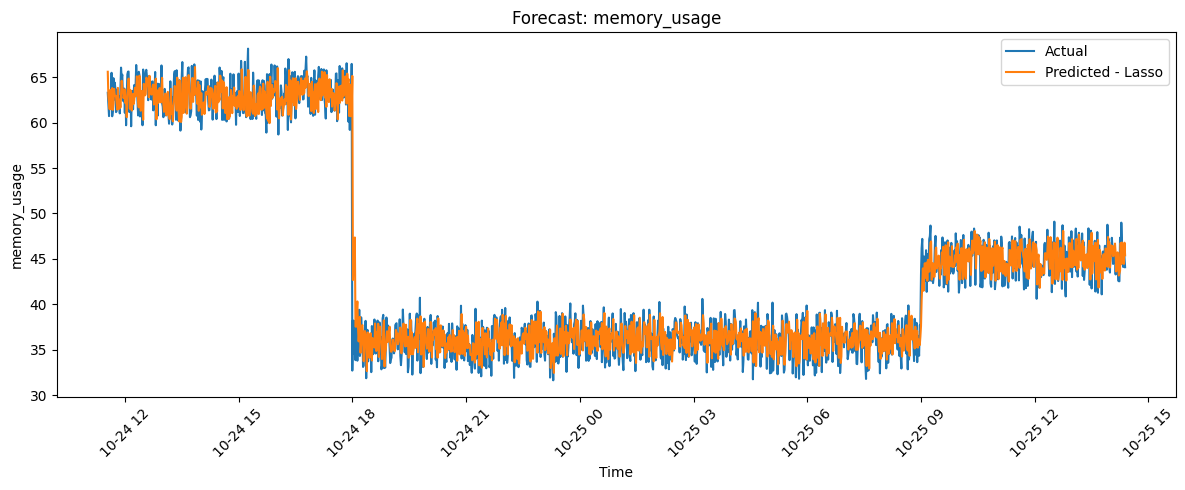


------------------------------------------------------------
Final Model Comparison
------------------------------------------------------------
                                Target          Model      MAE
6   avg_transaction_processing_time_ms          Ridge  24.5986
7   avg_transaction_processing_time_ms          Lasso  24.6016
4   avg_transaction_processing_time_ms  Random Forest  32.5430
5   avg_transaction_processing_time_ms        XGBoost  47.7118
11                     cpu_utilization          Lasso   2.9937
10                     cpu_utilization          Ridge   2.9938
8                      cpu_utilization  Random Forest   4.0276
9                      cpu_utilization        XGBoost   5.3830
15                        memory_usage          Lasso   1.9104
14                        memory_usage          Ridge   1.9104
12                        memory_usage  Random Forest   3.0628
13                        memory_usage        XGBoost   4.5306
1                 overall_success_r

In [10]:
'''2a) Implement time-series forecasting models to predict transaction success rates, API latency, and resource utilization'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

df = pd.read_csv("infrastructure_metrics_train.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df=df.sort_values("timestamp").reset_index(drop=True)

success_cols = [
    "neft_success_rate",
    "imps_success_rate",
    "rtgs_success_rate",
    "auth_success_rate"
]

df["overall_success_rate"] = df[success_cols].mean(axis=1)

print("\nThe target variables we want to predict are overall success rate, avg transaction processing time, cpu utilization, memory usage.")
targets = [
    "overall_success_rate",
    "avg_transaction_processing_time_ms",
    "cpu_utilization",
    "memory_usage"
]
print("\nWe will need to create time-series features that the computer can understand by building lag features/time features that the models can look backward in time to predict what happens next")
print()
def create_features(df,target):

  data = df[
      ["timestamp", target]
  ].copy()
  #previous values
  data["lag_1"] = data[target].shift(1)
  data["lag_5"] = data[target].shift(5)
  data["lag_10"] = data[target].shift(10)

  #tTime features
  data["hour"] = data["timestamp"].dt.hour
  data["minute"] = data["timestamp"].dt.minute

  data = data.dropna()

  return data

all_results = []

print("\nLets run forecasting using models for each target")

for target in targets:
  print("\n" + "-" *40)
  print("Forecasting:", target)
  print("-"*60)

  data = create_features(df, target)

  #divide data into 80% training and 20% testing
  train_size = int(len(data)*0.80)
  test_size = len(data) - train_size

  #first 80% of the rows
  train_data = data.head(train_size)

  #last 20% of the rows
  test_data = data.tail(test_size)

  print("Training rows: ", len(train_data))
  print("Testing rows: ", len(test_data))

  #select the features

  feature_columns = [
      "lag_1",
      "lag_5",
      "lag_10",
      "hour",
      "minute"
  ]

  X_train = train_data[feature_columns]
  y_train = train_data[target]

  X_test = test_data[feature_columns]
  y_test = test_data[target]

  #need to define the models: random forest, xgboost, ridge, lasso
  models = {
      "Random Forest":
        RandomForestRegressor(
            n_estimators=100,
            random_state=42
        ),
      "XGBoost":
        XGBRegressor(
            n_estimators=100,
            max_depth=4,
            learning_rate=0.05,
            objective="reg:squarederror",
            random_state=42
        ),

      "Ridge":
        make_pipeline(
            StandardScaler(),
            Ridge(alpha=1.0)
        ),
      "Lasso":
        make_pipeline(
            StandardScaler(),
            Lasso(
                alpha=0.01,
                max_iter=5000
            )
        )
  }
  best_model_name = None
  best_mae = float("inf")
  best_predictions=None

  for model_name, model in models.items():
    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    #calculate error
    mae = mean_absolute_error(
        y_test,
        predictions
    )

    print(
        f"{model_name} MAE: {mae:.3f}"
    )

    result = {
        "Target": target,
        "Model": model_name,
        "MAE": mae
    }
    all_results.append(result)

    #lets check if this is the best model such that mae < best mae:
    if mae < best_mae:
        best_mae = mae
        best_model_name = model_name
        best_predictions = predictions

  print("\nBest Model:", best_model_name)
  print(
      f"Best MAE: {best_mae:.3f}"
  )

  plt.figure(figsize=(12,5))
  plt.plot(
      test_data["timestamp"],
      y_test,
      label="Actual"
  )

  plt.plot(
      test_data["timestamp"],
      best_predictions,
      label=f"Predicted - {best_model_name}"
  )

  plt.title(
      f"Forecast: {target}"
  )

  plt.xlabel("Time")
  plt.ylabel(target)
  plt.legend()
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

results_df = pd.DataFrame(all_results)
print("\n" + "-"*60)
print("Final Model Comparison")
print("-"*60)
results_df =results_df.sort_values(
    by=["Target","MAE"]
)

print(
    results_df.round(4)
)

print("The models use the previous 1, 5, and 10 minutes plus the current hour/minute to help me predict the key performance indicator in the testing period.\n The MAE tells me how far the predictions are from the real values. ")
print("I orginally started with 8,064 rows, but first 10 rows disppear becase of data['lag_10'] = data[target.shift(10)]")
print("XGBoost is the better model used (compared to Random Forest, Ridge Regression and Lasso Regression) because it achieved the lowest Mean absolute error \nfor predicting overall transaction success rate even though Ridge and Lasso produced same performance.")
print("Blue color is ACtual Success Rate and Orange is the XGBoost Predicted Success Rate")
print("My XGBoost predicted success rate is extremely stable at 99% especially since it stays close to the middle of the graph")


Our goal is to predict incident criticality using key performance indicator values. We will predict whether an incident is 0 is non-critical or 1 is critical (target variable being y=data['is_critical'])
CPU utilization + Memory usage + DB connection usage + Error rate + NEFT success rate + IMPS success rate + RTGS success rate + Transaction processing time -->
 Random Forest Classifier --> Critical/Non-Critical --> Probability of Critical Incident
Looking at these key performance indicators, does this look like a critical banking system incident????

Training Rows: 134

Testing Rows: 34

Model results:
------------------------------------------------
Accuracy:  1.0
Precision:  1.0
Recall:  1.0
F1 Score: 1.0
ROC-AUC : 1.0

Confusion Matrix:
[[28  0]
 [ 0  6]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00         6

    accuracy                           1.

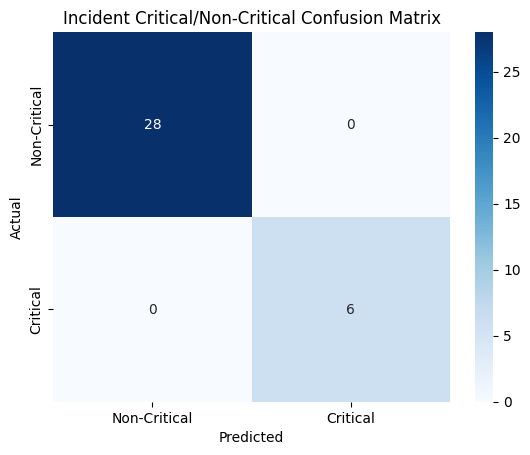


5-Fold Cross-Validation
-------------------------------
Average cv accuracy: 1.0
Average cv F1 score:  1.0

Feature Importance: 
--------------------------------
memory_usage                          0.262782
cpu_utilization                       0.214383
db_connection_pool_usage              0.206331
neft_success_rate                     0.155707
application_error_rate                0.154596
network_throughput_mbps               0.002245
imps_success_rate                     0.001893
avg_transaction_processing_time_ms    0.001152
rtgs_success_rate                     0.000912
dtype: float64

Model saved as incident_criticaluty_model.joblib - joblib is a python library, serialized python object not meant for human reading, used to save a trained machine-learning model to a file and load it back for later uses,
 without training again

New Incident Prediction
-------------------------------------
Prediction: CRITICAL INCIDENT
Probability of being critical: 1.0


In [11]:
'''2b) Build a classification model to predict incident criticality based on KPIs'''

from pathlib import Path
import pandas as pd
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
print("\nOur goal is to predict incident criticality using key performance indicator values. We will predict whether an incident is 0 is non-critical or 1 is critical (target variable being y=data['is_critical'])")
print("CPU utilization + Memory usage + DB connection usage + Error rate + NEFT success rate + IMPS success rate + RTGS success rate + Transaction processing time -->\n Random Forest Classifier --> Critical/Non-Critical --> Probability of Critical Incident")
print("Looking at these key performance indicators, does this look like a critical banking system incident????")
#load the data from incident_reports.csv

data=pd.read_csv("incident_reports.csv")

#convert timestamp into a real date/time column
data["timestamp"] = pd.to_datetime(data["timestamp"])

#sort the incidents from oldest to newest using timestamp column
data = data.sort_values("timestamp")
data = data.reset_index(drop=True)

#choose the key performance indicator features

features = [
    "cpu_utilization",
    "memory_usage",
    "db_connection_pool_usage",
    "network_throughput_mbps",
    "application_error_rate",
    "neft_success_rate",
    "imps_success_rate",
    "rtgs_success_rate",
    "avg_transaction_processing_time_ms"
]

#X will contain the key performance indicator values that will be used by our model
X = data[features]

#y contains the answer we want the model to learn
#0 is for non critical
#1 is for critical
y = data["is_critical"]

#split the data into training and testing
#80% of the data is going to be used to training the data
#20% will be used to test the model
#model is going to learn from older incidents and will be tested on newer incidents


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle = False # is used because the records are ordered by time, so no shuffling
)

print("\nTraining Rows:", len(X_train))
print("\nTesting Rows:", len(X_test))


#create the random forest model
model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state = 42
)

#train the model
model.fit(X_train, y_train)

# make predictions
#predict 0 or 1 for each test row
predictions = model.predict(X_test)

#predict_proba gives 2 probability columns:
#column 0 for the probability of non-critical
#column 1 for the probabiltiy of critical
probability_values = model.predict_proba(X_test)

probability_table = pd.DataFrame(
    probability_values,
    columns=["non-critical_probability", "critical_probability"]
)

critical_probabilities = probability_table["critical_probability"]

#evaluate the model
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
roc_auc = roc_auc_score(y_test, critical_probabilities)

print("\nModel results:")
print("------------------------------------------------")
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("F1 Score:", f1)
print("ROC-AUC :", roc_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions))

cm = confusion_matrix(y_test, predictions)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Critical", "Critical"],
    yticklabels=["Non-Critical", "Critical"]
)

plt.title("Incident Critical/Non-Critical Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#cross-validation checks the model several times using different parts of the complete dataset
accuracy_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

f1_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="f1"
)

average_cv_accuracy = accuracy_scores.mean()
avg_cv_f1 = f1_scores.mean()

print("\n5-Fold Cross-Validation")
print("-------------------------------")
print("Average cv accuracy:", average_cv_accuracy)
print("Average cv F1 score: ", avg_cv_f1)

#Feature Importance
#Lets train the final model using all the available labeled data
model.fit(X, y)

importance = pd.Series(
    model.feature_importances_, #tells me how important each input feature was for making this prediction
    index=features
)

importance = importance.sort_values(ascending=False)

print("\nFeature Importance: ")
print("--------------------------------")
print(importance)


#Lets Save the Model
joblib.dump(model, "incident_criticality_model.joblib")#joblib is a python library used to save a trained machine-learning model to a file and load it back for later uses, without training again
print("\nModel saved as incident_criticaluty_model.joblib - joblib is a python library, serialized python object not meant for human reading, used to save a trained machine-learning model to a file and load it back for later uses,\n without training again")


#lets predict a new incident, a testing example
new_incident = pd.DataFrame({
    "cpu_utilization": [90],
    "memory_usage": [86],
    "db_connection_pool_usage":[91],
    "network_throughput_mbps":[250],
    "application_error_rate":[14],
    "neft_success_rate":[87],
    "imps_success_rate":[99],
    "rtgs_success_rate":[99.5],
    "avg_transaction_processing_time_ms":[350]
})

new_prediction = model.predict(new_incident)[0]
new_probability_values = model.predict_proba(new_incident)

new_probability_table = pd.DataFrame(
    new_probability_values,
    columns=["non_critical_probability","critical_probability"]
)

new_probability = new_probability_table.loc[0, "critical_probability"]




print("\nNew Incident Prediction")
print("-------------------------------------")

if new_prediction==1:
  print("Prediction: CRITICAL INCIDENT")
else:
  print("Prediction: NON-CRITICAL INCIDENT")

print("Probability of being critical:", new_probability)



Let use IsolationForest Model to help with our anomaly detection prediction:
Anomaly Counts:
anomaly_status
Normal     9878
Anomaly     202
Name: count, dtype: int64

Average Key Performance Indicator values:
                cpu_utilization  memory_usage  db_connection_pool_usage  \
anomaly_status                                                            
Anomaly               63.816733     57.466139                 52.267921   
Normal                48.823281     43.915019                 39.045515   

                application_error_rate  neft_success_rate  
anomaly_status                                             
Anomaly                       4.767327          97.836040  
Normal                        1.944928          98.000625  

Lets create a bar chart for better visualization: Normal vs. Anomaly Counts


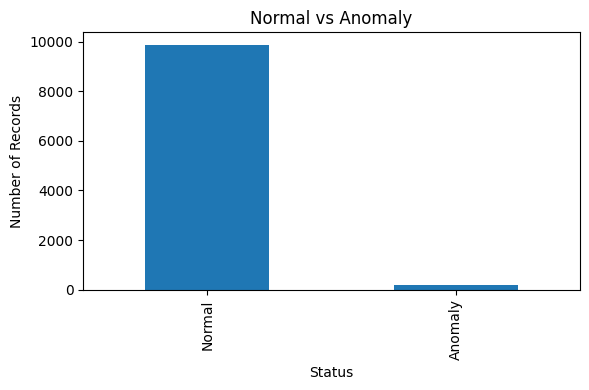


lets plot the graph to make it easy to visualize: 


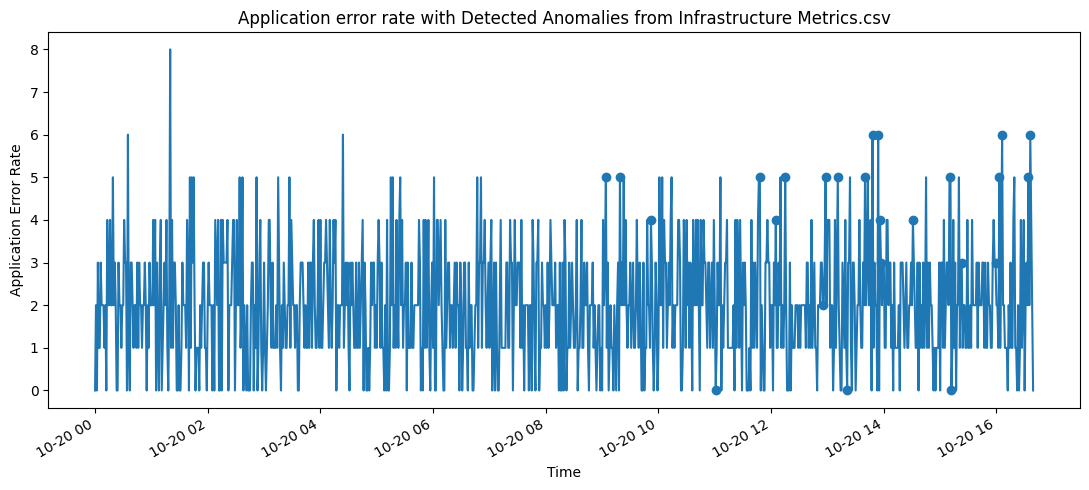

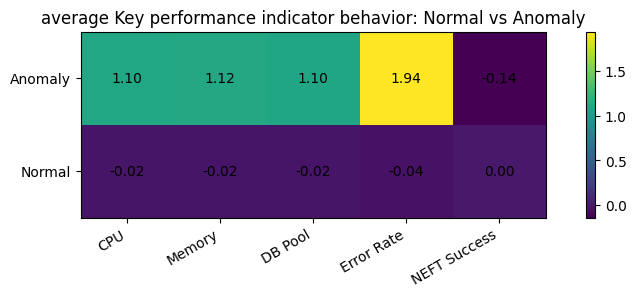

In [12]:
'''2c) Apply anomaly detection to identify unusual metric behavior'''
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

#load the data
data = pd.read_csv("infrastructure_metrics.csv")
data["timestamp"] = pd.to_datetime(data["timestamp"])

features = [
    "cpu_utilization",
    "memory_usage",
    "db_connection_pool_usage",
    "application_error_rate",
    "neft_success_rate",
]

X = data[features]

print("\nLet use IsolationForest Model to help with our anomaly detection prediction:")

model = IsolationForest(
    contamination=0.02,
    random_state =42
)

data["anomaly"] = model.fit_predict(X)

data["anomaly_status"] = data["anomaly"].map({
    1:"Normal",
    -1:"Anomaly"
})

print("Anomaly Counts:")
print(data["anomaly_status"].value_counts())

print("\nAverage Key Performance Indicator values:")
average_values= data.groupby("anomaly_status")[features].mean()
print(average_values)

print("\nLets create a bar chart for better visualization: Normal vs. Anomaly Counts")
counts = data["anomaly_status"].value_counts()

fig, ax = plt.subplots(figsize=(6,4))
counts.plot(kind="bar", ax=ax)

ax.set_title("Normal vs Anomaly")
ax.set_xlabel("Status")
ax.set_ylabel("Number of Records")
fig.tight_layout()

bar_path = "anomaly_count_chart.png"
plt.savefig(bar_path, dpi=200, bbox_inches="tight")
plt.show()

print("\nlets plot the graph to make it easy to visualize: ")
plot_data = data.head(1000)
fig,ax = plt.subplots(figsize=(11,5))
ax.plot(
    plot_data["timestamp"],
    plot_data["application_error_rate"]
)

anomalies = plot_data[plot_data["anomaly_status"] =="Anomaly"]

ax.scatter(
    anomalies["timestamp"],
    anomalies["application_error_rate"]
)

ax.set_title("Application error rate with Detected Anomalies from Infrastructure Metrics.csv")
ax.set_xlabel("Time")
ax.set_ylabel("Application Error Rate")

fig.autofmt_xdate()
fig.tight_layout()

time_path = "anomaly_error_rate_timeseries.png"
plt.savefig(time_path, dpi=200, bbox_inches="tight")
plt.show()

#heatmap
#lets make sure to use standardization for heatmap so key performance indicators with different measurement scales can be compared evenly

scaler = StandardScaler()

standardized_values = scaler.fit_transform(data[features])

standardized_data = pd.DataFrame(
    standardized_values,
    columns=features
)

standardized_data["anomaly_status"] = data["anomaly_status"]

heatmap_data = standardized_data.groupby(
    "anomaly_status"
)[features].mean()

fig, ax = plt.subplots(figsize=(9,3))
image = ax.imshow(heatmap_data)

ax.set_title("average Key performance indicator behavior: Normal vs Anomaly")

ax.set_xticks(range(len(features)))
ax.set_xticklabels(
    ["CPU","Memory","DB Pool", "Error Rate","NEFT Success"], rotation = 30, ha="right"
)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

for row in range(len(heatmap_data.index)):
  for column in range(len(features)):
    value = heatmap_data.iloc[row, column]
    ax.text(
        column,
        row,
        f"{value:.2f}",
        ha="center",
        va="center"
    )
fig.colorbar(image, ax=ax)
fig.tight_layout()

heatmap_path = "anomaly_kpi_heatmap.png"
plt.savefig(heatmap_path, dpi=200, bbox_inches="tight")
plt.show()


Incident_reports.csv Dataset Shape: (168, 14)
Training Records: 134
Testing Records: 34

================Model Comparison:=================
                 Model  Accuracy  Precision  Recall  F1 Score  MAE  RMSE
0  Logistic Regression       1.0        1.0     1.0       1.0  0.0   0.0
1        Decision Tree       1.0        1.0     1.0       1.0  0.0   0.0
2        Random Forest       1.0        1.0     1.0       1.0  0.0   0.0
3    Gradient Boosting       1.0        1.0     1.0       1.0  0.0   0.0


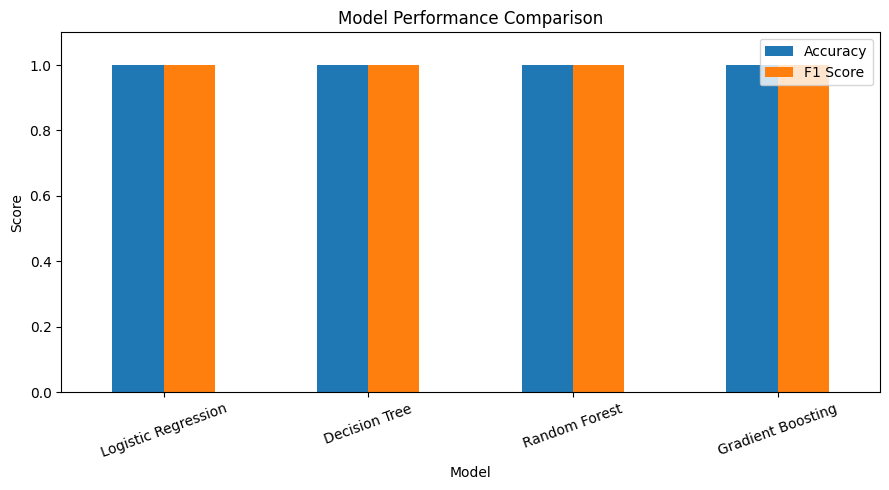


Lets use Random Forest as Final Model:


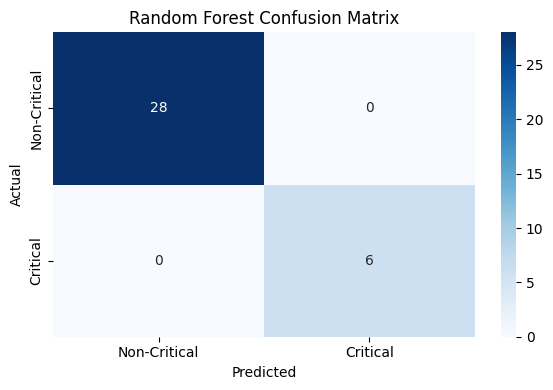


Random Forest Classification Report
              precision    recall  f1-score   support

Non-Critical       1.00      1.00      1.00        28
    Critical       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34


Lets Predict a New Incident

New Incident Prediction
Prediction: Critical Incident
Probability of being Critical Incident: 1.0


<Axes: xlabel='Model'>

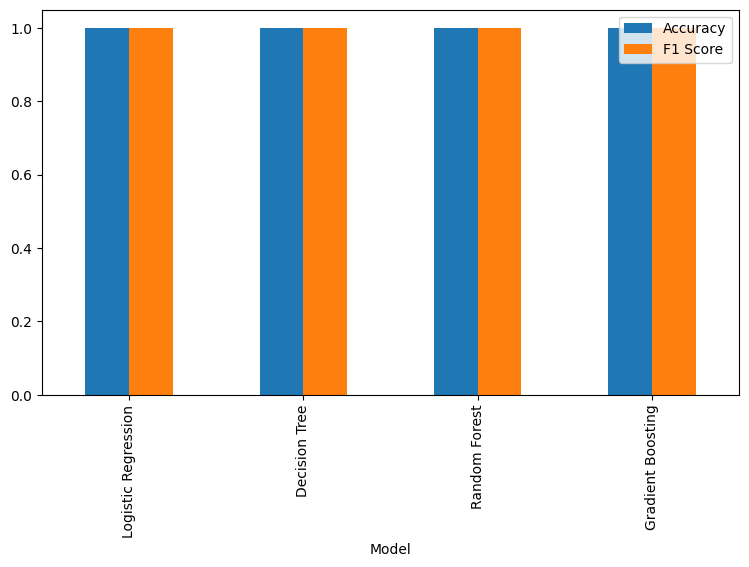

In [29]:
'''2c) Evaluate model performance using metrics such as RMSE, MAE, Accuracy, and F1-score '''
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    confusion_matrix,
    classification_report
)

data = pd.read_csv("incident_reports.csv")
data["timestamp"] = pd.to_datetime(data["timestamp"])
data = data.sort_values("timestamp") #sorting incidents from oldest to newest
data = data.sort_values("timestamp").reset_index(drop=True)
print("Incident_reports.csv Dataset Shape:", data.shape)
features = [
    "cpu_utilization",
    "memory_usage",
    "db_connection_pool_usage",
    "network_throughput_mbps",
    "application_error_rate",
    "neft_success_rate",
    "imps_success_rate",
    "rtgs_success_rate",
    "avg_transaction_processing_time_ms"
]

X = data[features]
y = data["is_critical"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, shuffle=False
)

print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))

models = {
    "Logistic Regression": LogisticRegression( #simple baseline classifier
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier( #learns key performance indicator decision rules
        max_depth=5,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier( #combines many decision trees
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier( #builds trees sequentially to improve errors
        random_state=42
    )
}

results = []

for model_name in models:
      model = models[model_name]
      model.fit(X_train, y_train)
      predictions= model.predict(X_test)
      accuracy=accuracy_score(
          y_test,
          predictions
      )
      precision=precision_score(
          y_test,
          predictions,
          zero_division=0
      )

      recall = recall_score(
          y_test,
          predictions,
          zero_division=0
      )

      f1 = f1_score(
          y_test,
          predictions,
          zero_division=0
      )
      mae = mean_absolute_error(
          y_test,
          predictions
      )
      mse = mean_squared_error(
          y_test,
          predictions
      )
      rmse = np.sqrt(mse)

      results.append([
          model_name,
          accuracy,
          precision,
          recall,
          f1,
          mae,
          rmse
      ])
results_table = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "MAE",
        "RMSE"
    ]
)

print("\n================Model Comparison:=================")
print(results_table.round(3))

chart_data = results_table.set_index("Model")
chart_data[["Accuracy","F1 Score"]].plot(kind="bar", figsize=(9,5))

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0,1.1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print("\nLets use Random Forest as Final Model:")
final_model= models["Random Forest"]
random_forest_predictions = final_model.predict(
    X_test
)

cm = confusion_matrix(
    y_test,
    random_forest_predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Non-Critical",
        "Critical"
    ],
    yticklabels=[
        "Non-Critical",
        "Critical"
    ]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("\nRandom Forest Classification Report")
print(
    classification_report(
        y_test,
        random_forest_predictions,
        target_names =[
            "Non-Critical",
            "Critical"
        ]
    )
)
print("\nLets Predict a New Incident")
new_incident=pd.DataFrame({
    "cpu_utilization":[90],
    "memory_usage":[86],
    "db_connection_pool_usage":[91],
    "network_throughput_mbps":[250],
    "application_error_rate":[14],
    "neft_success_rate":[87],
    "imps_success_rate":[99],
    "rtgs_success_rate":[99.5],
    "avg_transaction_processing_time_ms":[350]
})

new_prediction = final_model.predict(
    new_incident
)[0]

probabilities = final_model.predict_proba(
    new_incident
)

critical_probability = probabilities[0][1]
print("\nNew Incident Prediction")
if new_prediction==1:
  print("Prediction: Critical Incident")
else:
  print("Prediction: Non-Critical Incident")

print("Probability of being Critical Incident:", critical_probability)

chart_data[
    ["Accuracy", "F1 Score"]
].plot(
    kind="bar",
    figsize=(9,5)
)

In [ ]:
'''Task 3: AI-Driven incident analysis and root cause automationw

Preprocess log data using NLP techniques such as TF-IDF or word embeddings
Apply unsupervised clustering to group logs into infrastructure issues and business KPI issues
Build a knowledge base from historical incidents and documentation
Integrate a retrieval-augmented generation (RAG) pipeline to fetch relevant incidents and documents
Implement an AI assistant using LangGraph or LangChain to answer queries
Generate AI-based root cause summaries and recommendations

'''

In [30]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 18.1 MB/s eta 0:00:00


In [46]:
'''Preprocess log data using NLP techniques such as TF-IDF or word embeddings'''

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from textblob import TextBlob
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import(
    CountVectorizer,
    TfidfVectorizer
)
from gensim.models import Word2Vec

data = pd.read_csv("application_logs.csv")
print("Dataset shape:", data.shape)

print("\nLets clean text using regular expression:")
def clean_text(text):
  text = str(text).lower()

  text = re.sub(r"^(info|error|warning):\s*", "", text) #i.e. ERROR: Server is down will become server is down...removes ERROR:
  text = re.sub(r"\b(?:txt|usr|srv)[-_]?\d+\b", " ", text) #remove IDs such as TXT123, USR45, srv-10 and replace with space
  text = re.sub(r"\b\d+(?:\.\d+)?(?:ms|%|mb|gb)?\b", " ", text) #remove numbers such as 500, 800ms, 90%
  text = re.sub(r"[^a-z\s]", " ", text) #remove punctuation
  text = re.sub(r"\s+", " ", text)

  return text.strip()

data["clean_message"] = data["log_message"].apply(clean_text)

#stemming and lemmzatization

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

try:
  lemmatizer.lemmatize("transactions")

except LookupError:

  nltk.download("wordnet")
  nltk.download("omw-1.4")



def stem_text(text):

    words = text.split()

    result = []

    for word in words:

        result.append(
            stemmer.stem(word) #i.e. running -> run
        )

    return " ".join(result)



def lemmatize_text(text):
    words = text.split()

    result = []

    for word in words:
        result.append(
            lemmatizer.lemmatize(word) #find the dictionary/base for of each word
        )
    return " ".join(result)


data["stemmed_message"] = data["clean_message"].apply(stem_text)
data["lemmatized_message"] = data["clean_message"].apply(lemmatize_text)




def get_sentiment(text):
  return TextBlob(text).sentiment.polarity#whether text sounds negative (-1), neutral (0)or positive (+1) percentage



data["sentiment"] = data["clean_message"].apply(get_sentiment)

bow = CountVectorizer(    #bag of words - take cleaned/lemmatized messages and count how often each word appears and put into table
    stop_words="english", #ignore common words like 'the,is,a,and,to...'
    max_features=20 #keeps 20 most important words in dataset
)

bow_matrix = bow.fit_transform(
    data["lemmatized_message"]
)

bow_data = pd.DataFrame(
    bow_matrix.toarray(), #matrix of bag of words where each cell has total amount words found in the messages
    columns=bow.get_feature_names_out()
)
print("\nBag of Words features: ")
print(bow.get_feature_names_out())




#lets utilize bigram (two word phrase), such as gateway timeout, transaction failed, connection pool
bigram = CountVectorizer(
    stop_words = "english", #common words are ignored like 'the, is, a, an ...'
    ngram_range=(2,2), #i.e gateway timeout, timeout error
    max_features=15 #keeping 15 most important bigrams
)

bigram_matrix = bigram.fit_transform(
    data["lemmatized_message"] #convert each messages into numbers representing how many bigrams occur
)

print("\nImportant Bigrams:")

print(
    bigram.get_feature_names_out()
)




tfidf = TfidfVectorizer( #gives more importance to words that are useful for particular message and less importance to words that appear everywhere
    stop_words="english",
    max_features = 25,
    #1 -> individual words
    #2 -> two-word phrases
    ngram_range=(1,2) #one word and two words
)

tfidf_matrix = tfidf.fit_transform(
    data["lemmatized_message"]
)

tfidf_data = pd.DataFrame( #turning the matrix into pandas dataframe to inspect tfidf score/how important that word is to rest of other words in dataset
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)

print("\nTF-IDF Features")

print(
    tfidf.get_feature_names_out()
)





sentences = []
print("\nLets convert every log into a list of words using WORD2VEC WORD EMBEDDINGS so that we can learn meaningful\n relationships between words based on the words around them:")
for message in data["lemmatized_message"]:
  sentences.append(
      message.split()
  )

word2vec_model = Word2Vec(
    sentences=sentences,
    vector_size=50, #each word will have 50 numbers
    window=5, #looks at words with 5 positions around the target word when learning relationships
    min_count=2, #learning words that appear 2 times in training data
    workers=4, #4 cpu threads/processes used to train model/training speed
    seed=42
)

print("\nSince Word2Vec gives you one vector per word, our model wants one vector per message. So we will need to average of all the word vectors in our entire message.")
def get_log_embedding(text):
  words = text.split()
  vectors = []
  for word in words:
    if word in word2vec_model.wv:
      vectors.append(word2vec_model.wv[word])

  if len(vectors) > 0:
    return np.mean(vectors, axis=0)
  return np.zeros(50)

log_embeddings = []
for message in data["lemmatized_message"]:
  log_embeddings.append(
      get_log_embedding(message)
  )

embedding_data = pd.DataFrame(
    log_embeddings
)

print("\nWord2Vec embedding shape:")
print(embedding_data.shape)
print("\n\nWord2Vec embedding data of the average of the whole messages:")
print(embedding_data)

Dataset shape: (5000, 3)

Lets clean text using regular expression:

Bag of Words features: 
['api' 'cache' 'completed' 'connection' 'current' 'database' 'detected'
 'duplicate' 'exceeded' 'failed' 'gateway' 'id' 'reason' 'refresh'
 'successfully' 'time' 'timeout' 'transaction' 'txn' 'user']

Important Bigrams:
['cache refresh' 'detected server' 'detected transaction'
 'duplicate transaction' 'failed transaction' 'id txn'
 'processed successfully' 'refresh completed' 'successfully id'
 'transaction detected' 'transaction failed' 'transaction id'
 'transaction processed' 'txn reason' 'user id']

TF-IDF Features
['api' 'completed' 'connection' 'current' 'database' 'detected'
 'detected transaction' 'exceeded' 'failed' 'failed transaction' 'gateway'
 'id' 'id txn' 'reason' 'successfully' 'time' 'timeout' 'transaction'
 'transaction detected' 'transaction failed' 'transaction id' 'txn'
 'txn reason' 'user' 'user id']

Lets convert every log into a list of words using WORD2VEC WORD EMBEDDIN

In [54]:
'''3b) Apply unsupervised clustering to group logs into infrastructure issues and business KPI issues'''

import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

data = pd.read_csv("application_logs.csv")

#lets keep only the error and warning logs and ignore the rest
issues = data[
    data["log_level"].isin(["ERROR","WARNING"]).copy()
]

#lets convert that log messages into TF-IDF numbers
tfidf = TfidfVectorizer(
    stop_words = "english",
    max_features=50
)

X=tfidf.fit_transform(
    issues["log_message"]
)

#lets create two clusters here:
model = KMeans(
    n_clusters=2,
    random_state=42
)

issues["cluster"] =model.fit_predict(X)

#lets look at the important words like we did in word2vec in each cluster
words = np.array(
    tfidf.get_feature_names_out() #gets the vocabulary words in the list
)
#we are taking the ERROR and WARNING log messages ->convert them to TF-IDF numbers and auto split them into 2 groups and find the words that characterized each group
for cluster in range(2): #find the 5 features with highest importance in this cluster/each cluster, then convert the indexes back to words and print
  important_words = model.cluster_centers_[
      cluster
  ].argsort()[-5:]

  print(
      "Cluster",
      cluster,
      ":",
      words[important_words]
  )

issues["issue_type"] = issues["cluster"].map({
    0: "Infrastructure Issue",
    1: "Business Key Performance Indicator Issue"
})

print("\n\nNumber of logs in each group:")
print(issues["issue_type"].value_counts())
print("\nSample Results:")
print(
    issues[
        [
            "log_message",
            "issue_type"
        ]
    ].head(15)
)

print("\n")

print("\nWe used TF-IDF to convert application_logs.csv messages into numberical features. K-Means clustering \nwas then applied with two clusers to auto group similar logs. We then analyzed important terms in each cluster\n and resulted into 2 clusters: Infrastructure Issues and Business Key Performance Indicator issues")
print("\nInfrastructure logs contained issues like API, Disk, bottlenecks and memory, while\n business logs contained transactions, failures, NEFT and gateway timeouts; two clusters\n\n\n")

Cluster 0 : ['detected' 'failed' 'id' 'error' 'transaction']
Cluster 1 : ['srv' 'exceeded' 'time' 'api' 'warning']


Number of logs in each group:
issue_type
Infrastructure Issue                        2623
Business Key Performance Indicator Issue    1138
Name: count, dtype: int64

Sample Results:
                                          log_message  \
1   ERROR: NEFT transaction failed. Transaction ID...   
2   ERROR: Database connection pool exhausted. Con...   
3   ERROR: IMPS transaction failed. Transaction ID...   
4   WARNING: Memory usage approaching threshold on...   
5   ERROR: High CPU utilization detected on server...   
6   ERROR: Customer authentication failed. User ID...   
7   WARNING: Payment gateway response time exceede...   
9       ERROR: Disk I/O bottleneck detected on srv-18   
11  WARNING: Payment gateway response time exceede...   
13  WARNING: Payment gateway response time exceede...   
14  WARNING: Payment gateway response time exceede...   
15  ERROR: Custom

/tmp/ipykernel_974/2553500683.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  issues["cluster"] =model.fit_predict(X)
/tmp/ipykernel_974/2553500683.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  issues["issue_type"] = issues["cluster"].map({


In [68]:
'''3d) Integrate a retrieval-augmented generation (RAG) pipeline to fetch relevant incidents and documents'''

from pathlib import Path
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

with open("incident_knowledge_base.txt", "r", encoding="utf-8") as file:
  knowledge_text = file.read()
#since each incident on txt file is separated by =======
kb_documents = knowledge_text.split(
    "================================================================================"
)

cleaned_documents = []
for doc in kb_documents:
  doc = doc.strip()
  if doc:
    cleaned_documents.append(doc)
kb_documents = cleaned_documents
print("\n RAG is retrieval augmented generation: (Retrieval Find useful information:) query -> search knowledge base-> retrieve relvant documents. \n(augmentation Combine the retrieved information with the original problem:) original issue + RCA document + similar historical incidents \n (generation Provide all of that context to an AI model)")
print("\nLets load the past incident reports:")
incidents = pd.read_csv("incident_reports.csv")

incident_documents = []

for _, row in incidents.iterrows():
  symptoms = []
  if row["cpu_utilization"] > 85:
    symptoms.append("high cpu utilization")

  if row["memory_usage"] > 80:
    symptoms.append("memory usage spike")

  if row["db_connection_pool_usage"]>85:
    symptoms.append("database connection pool exhaustion")

  if row["neft_success_rate"] < 90: #we do not want failures
    symptoms.append("neft transaction failures")

  if row["application_error_rate"] > 8:
    symptoms.append("high application error rate")

  incident_text = (
      f"Past Incident {row['incident_id']}."
      f"Type: {row['incident_type']}."
      f"Severity: {row['severity']}."
      f"Symptoms: {' '.join(symptoms)}."
      f"CPU: {row['cpu_utilization']:.1f}."
      f"Memory: {row['memory_usage']:.1f}."
      f"DB Pool: {row['db_connection_pool_usage']:.1f}."
      f"Error Rate: {row['application_error_rate']}."
      f"NEFT Success Rate: {row['neft_success_rate']:.1f}."
  )

  incident_documents.append(
      incident_text
  )

documents = (kb_documents + incident_documents)

document_types = (
    (["Knowledge Base"] * len(kb_documents)) + (["Past Incident"]*len(incident_documents))
)

print(document_types)

print("\n")



vectorizer = TfidfVectorizer(
    stop_words = "english"
)

document_vectors = vectorizer.fit_transform(documents)


#lets retrieve relevant documents
def retrieve(query, top_k=3):
  query_vector = vectorizer.transform(
      [query]
  )

  similarities = cosine_similarity( #compares the new problem against all stored documents (compares to high cpu doc, database doc, etc....past incident inc001, inc002, etc.)
      query_vector,
      document_vectors
  )[0]

  best_matches = similarities.argsort()[
      ::-1
  ][:top_k] #retrieve the best results from highest similarity score

  results = []

  for index in best_matches:
    results.append({
        "type":document_types[index],
        "score":similarities[index],
        "text":documents[index]
    })
  return results

#providing a simple rag response
def rag_response(query):
  results = retrieve(
      query,
      top_k=3
  )

  print("\nUser Issue:")
  print(query)
  print("\nRetrieved Context:")

  for number, result in enumerate(
      results,
      start=1
  ):
      print(
          "\nResult",
          number
      )
      print(
          "Source:",
          result["type"]
      )
      print(
          "Similarity:",
          round(
              result["score"],
              3
          )
      )

      print(result["text"])

  print("\nRag Summary:")

  print("The System retrieved the most knowleged base document and similar historical incidents.\n The context can now be passed to an AI model to generated the final root-cause \nanalysis and recommended remediation steps.")


print("\nLets test the Rag Pipeline:\n")
query = ("\nNEFT Transactions are failing with gateway timeout and the application error rate is high")
rag_response(query)





 RAG is retrieval augmented generation: (Retrieval Find useful information:) query -> search knowledge base-> retrieve relvant documents. 
(augmentation Combine the retrieved information with the original problem:) original issue + RCA document + similar historical incidents 
 (generation Provide all of that context to an AI model)

Lets load the past incident reports:
['Knowledge Base', 'Knowledge Base', 'Knowledge Base', 'Knowledge Base', 'Knowledge Base', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Incident', 'Past Inc

In [ ]:
'''3e) Implement an AI assistant using LangGraph or LangChain to answer queries'''

'''   PLEASE LOOK AT UNDER VOCAREUM FILE ---> finalCapstoneTask3LangchainAnswerQueries.ipynb '''

In [ ]:
''' Task 4: Visualization and deployment

Build a dashboard (Streamlit) to display:
Real-time and forecasted KPIs
Log classification results
AI-generated incident analyses
Create backend endpoints using FastAPI for model inference and log insights
Containerize components with Docker and orchestrate using Docker Compose
Deploy and test the system locally or on the cloud'''

In [1]:
pip install streamlit scikit-learn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 38.3 MB/s eta 0:00:00


In [4]:
'''Build a dashboard (Streamlit) to display:
Real-time and forecasted KPIs'''


'''please look at python file called dashboard_streamlit.py ran on visual studio '''

2026-08-11 02:45:46.983 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-11 02:45:46.987 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-11 02:45:46.991 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-11 02:45:46.994 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-11 02:45:47.000 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-11 02:45:47.002 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-11 02:45:47.008 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.



Lets set up the page first
